# Hypothesis testing

For use in Figure 8

Table of Contents:
1. Imports and load data
2. Set up how to run hypothesis test
3. Run hypothesis tests
4. Summarise results

## 1. Imports and load data

In [10]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import plotly.graph_objects as go


from flow_tree_utils import OBJECTS, plot_flow_tree, load_test_df, compute_extended_explore_traj, compute_explore_traj, generate_trajs_from_df, generate_flow_tree_from_trajs

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# Load test data into dataframe
test_df = load_test_df()

### Load explore df

In [11]:
# load explore df
explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
acc_dict = {}
for index, row in test_df[["Subject", "quartile", "subj_mean_acc"]].iterrows():
    subj, q, acc = row["Subject"], row["quartile"], row["subj_mean_acc"]
    if subj not in q_dict:
        q_dict[subj] = q
        acc_dict[subj] = acc

explore_df["quartile"] = explore_df["Subject"].map(q_dict)
explore_df["subject_mean_acc"] = explore_df["Subject"].map(acc_dict)

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["extended_explore_traj"] = explore_df["explore_path"].apply(compute_extended_explore_traj)
explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

NameError: name 'df' is not defined

## 2. Set up how to run hypothesis test

1. Compute Flow Trees
2. Compute features on Flow Trees
3. Run appropriate statistical test


In [12]:
from scipy.spatial.distance import pdist
from scipy import stats 


def vector_statistic(x, y, axis):
    mean_x = np.mean(x, axis=axis)
    mean_y = np.mean(y, axis=axis)
        
    # Calculate Euclidean distance
    dist = mean_x - mean_y
    # print(f"Distance between means: {dist}")  # Debug print

    return dist

def run_ttest(group1_reps, group2_reps, statistic=vector_statistic):
    # Perform a t-test on groups
    t_stat, p_value = stats.ttest_ind(group1_reps, group2_reps)
    print(f"Group 1 mean: {np.mean(group1_reps):.2f} (var={np.var(group1_reps):.2f}; n={len(group1_reps)})")
    print(f"Group 2 mean: {np.mean(group2_reps):.2f} (var={np.var(group2_reps):.2f}; n={len(group2_reps)})")
    print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

    # mean1, var1, n1 = np.mean(group1_reps), np.var(group1_reps), len(group1_reps)
    # mean2, var2, n2 = np.mean(group2_reps), np.var(group2_reps), len(group2_reps)
    # t = (mean1 - mean2) / np.sqrt((var1/n1 + var2/n2))
    # print("Number samples:", n1, n2)
    # print("T homemade:", t)

    return t_stat, p_value


def run_permutation_test(group1_reps, group2_reps, statistic=vector_statistic):
    res = stats.permutation_test((group1_reps, group2_reps), statistic, vectorized=True,
                       n_resamples=9999,# np.inf,
                       alternative='two-sided')
    print(f"Permutation test result: {res.statistic:.4} (p={res.pvalue:.4})")

    if len(group1_reps.shape) == 1:
        group1_reps = group1_reps.reshape(-1, 1)
    if len(group2_reps.shape) == 1:
        group2_reps = group2_reps.reshape(-1, 1)

    all_group_dist = pdist(np.concatenate([group1_reps, group2_reps]))

    within_group1_dist = pdist(group1_reps)
    within_group2_dist = pdist(group2_reps)
    within_group_dist = np.concatenate([within_group1_dist, within_group2_dist])

    print(f"Mean within group 1 dist: {np.mean(within_group1_dist):.2} (var={np.var(within_group1_dist):.2})")
    print(f"Mean within group 2 dist: {np.mean(within_group2_dist):.2} (var={np.var(within_group2_dist):.2})")
    print(f"Mean between all group dist: {np.mean(all_group_dist):.2} (var={np.var(all_group_dist):.2})")

    res2 = stats.permutation_test((within_group1_dist, all_group_dist), statistic, vectorized=True,
                       n_resamples=9999,#np.inf, 
                       alternative='less') # within group dist should be less than between
    print(f"Within group 1 dist vs among all: {res2.statistic:.4} (p={res2.pvalue:.4})")  
    t_stat, p_value = stats.ttest_ind(within_group1_dist, all_group_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")  

    res2 = stats.permutation_test((within_group2_dist, all_group_dist), statistic, vectorized=True,
                       n_resamples=9999,#np.inf, 
                       alternative='less') # within group dist should be less than between
    print(f"Within group 2 dist vs among all: {res2.statistic:.4} (p={res2.pvalue:.4})")  
    t_stat, p_value = stats.ttest_ind(within_group2_dist, all_group_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")  

    res2 = stats.permutation_test((within_group1_dist, within_group2_dist), statistic, vectorized=True,
                       n_resamples=9999,#np.inf, 
                       alternative='less') # within group dist should be less than between
    print(f"Within group 1 dist vs within group 2: {res2.statistic:.4} (p={res2.pvalue:.4})")  
    t_stat, p_value = stats.ttest_ind(within_group1_dist, within_group2_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")   

def euc_dist_between_means(x, y):
    return np.linalg.norm(np.mean(x, axis=0) - np.mean(y, axis=0))


def run_homemade_permutation_test(group1, group2, statistic=euc_dist_between_means, n_permutations=9999):
    observed = statistic(group1, group2)

    data = np.concatenate([group1, group2])
    rng = np.random.default_rng()

    n_samples = len(data)

    n_group1 = len(group1)

    perm_generator = (rng.permutation(n_samples)
                            for i in range(n_permutations))

    def _batch_generator(iterable, batch):
        """A generator that yields batches of elements from an iterable"""
        iterator = iter(iterable)
        if batch <= 0:
            raise ValueError("`batch` must be positive.")
        z = [item for i, item in zip(range(batch), iterator)]
        while z:  # we don't want StopIteration without yielding an empty list
            yield z
            z = [item for i, item in zip(range(batch), iterator)]


    null_distribution = []
    for indices in _batch_generator(perm_generator, batch=n_permutations):
        indices = np.array(indices) # shape: [num permutations, num samples]

        for permutation in indices:
            data_batch = data[permutation, ...]

            permuted_group1 = data_batch[:n_group1, ...]
            permuted_group2 = data_batch[n_group1:, ...]

            permuted_statistic = statistic(permuted_group1, permuted_group2)
            null_distribution.append(permuted_statistic)

    null_distribution = np.array(null_distribution)

    adjustment = 1
    n_resamples = n_permutations

    def less(null_distribution, observed):
        cmps = null_distribution <= observed #+ gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def greater(null_distribution, observed):
        cmps = null_distribution >= observed #- gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def two_sided(null_distribution, observed):
        pvalues_less = less(null_distribution, observed)
        pvalues_greater = greater(null_distribution, observed)
        pvalues = np.minimum(pvalues_less, pvalues_greater) * 2
        return pvalues

    pvalue = two_sided(null_distribution, observed)
    # print(f"Permutation test: {observed:.4f} (p={pvalue:.4f})")

    return observed, pvalue

# def run_hypothesis_test_on_df(df, column_name, groups):
    

## 3. Run hypothesis tests (refactor)

Steps:
1. Make groups
2. Run tests
3. Add results to df

Hypotheses tested:
1. Do quartiles have different group dynamics?
2. Do men and women have different group dynamics?

In [75]:
# Create a DataFrame to store hypothesis test results
def get_new_results_df():
    return pd.DataFrame(columns=[
        'hypothesis',
        'test_type',
        'group1_name',
        'group2_name',
        'group1_mean',
        'group2_mean',
        'group1_var',
        'group2_var',
        'group1_n',
        'group2_n',
        'statistic',
        'p_value',
        'significant',
        'metric',
        'notes'
    ])

all_results_df = get_new_results_df()

In [77]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights) / max_weight
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    features = [
        num_nodes,
        num_leaves,
        depth,
        avg_branching_factor,
        backbone_thickness,
        diameter
    ]
    
    return features

def compare_flow_tree_groups(results_df, group1_trees, group2_trees, normalise=False, include_embeddings=True, hypothesis_test_types=["permutation"], group1_name="Group 1", group2_name="Group 2", hypothesis=""):
    """Compare two groups of flow trees on various structural metrics.
    
    Args:
        results_df
        group1_trees: List of networkx graphs for first group
        group2_trees: List of networkx graphs for second group 
        group1_name: Name of first group for results
        group2_name: Name of second group for results
        hypothesis: Hypothesis being tested
        
    Returns:
        DataFrame containing test results
    """
    feature_names = ['num_nodes', 'num_leaves', 'depth',  'avg_branching_factor', 'backbone_thickness','diameter',]

    # Add embeddings to features arrays
    group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
    group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

    # Test each feature
    for i, feature_name in enumerate(feature_names):
        group1_feature = group1_features[:, i]
        group2_feature = group2_features[:, i]

        if normalise:
            # Normalize features to 0-1 range
            all_features = np.concatenate([group1_feature, group2_feature])
            feature_min = np.min(all_features)
            feature_max = np.max(all_features)
            
            # Avoid division by zero if min==max
            if feature_max > feature_min:
                group1_feature = (group1_feature - feature_min) / (feature_max - feature_min)
                group2_feature = (group2_feature - feature_min) / (feature_max - feature_min)
        
        if "t-test" in hypothesis_test_types:
            # T-test
            t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
            results_df.loc[len(results_df)] = {
                'hypothesis': hypothesis,
                'test_type': 't-test',
                'group1_name': group1_name,
                'group2_name': group2_name,
                'group1_mean': np.mean(group1_feature),
                'group2_mean': np.mean(group2_feature),
                'group1_var': np.var(group1_feature),
                'group2_var': np.var(group2_feature),
                'group1_n': len(group1_feature),
                'group2_n': len(group2_feature),
                'statistic': t_stat,
                'p_value': p_val,
                'significant': p_val < 0.05,
                'metric': feature_name,
                'notes': f'Comparing flow tree {feature_name} between {group1_name} and {group2_name}'
            }

        if "permutation" in hypothesis_test_types:
            # Permutation test
            perm_stat, perm_p = run_homemade_permutation_test(group1_feature, group2_feature)
            results_df.loc[len(results_df)] = {
                'hypothesis': hypothesis,
                'test_type': 'permutation',
                'group1_name': group1_name,
                'group2_name': group2_name,
                'group1_mean': np.mean(group1_feature),
                'group2_mean': np.mean(group2_feature),
                'group1_var': np.var(group1_feature),
                'group2_var': np.var(group2_feature),
                'group1_n': len(group1_feature),
                'group2_n': len(group2_feature),
                'statistic': perm_stat,
                'p_value': perm_p,
                'significant': perm_p < 0.05,
                'metric': feature_name,
                'notes': f'Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}'
            }

    if include_embeddings:
        # Initialize Graph2Vec embedder
        test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
        test_flow_tree_embedder.fit(group1_trees + group2_trees)

        # Get embeddings
        group1_embeddings = test_flow_tree_embedder.infer(group1_trees)
        group2_embeddings = test_flow_tree_embedder.infer(group2_trees)

        # Get PCA-1 and PCA-2 of embeddings?

        # Permutation test
        perm_stat, perm_p = run_homemade_permutation_test(group1_embeddings, group2_embeddings)
        results_df.loc[len(results_df)] = {
            'hypothesis': hypothesis,
            'test_type': 'permutation',
            'group1_name': group1_name,
            'group2_name': group2_name,
            'group1_mean': np.mean(group1_embeddings),
            'group2_mean': np.mean(group2_embeddings),
            'group1_var': np.var(group1_embeddings),
            'group2_var': np.var(group2_embeddings),
            'group1_n': len(group1_embeddings),
            'group2_n': len(group2_embeddings),
            'statistic': perm_stat,
            'p_value': perm_p,
            'significant': perm_p < 0.05,
            'metric': "graph2vec embeddings",
            'notes': f'Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}'
        }

        group1_features = np.append(group1_features, np.mean(group1_embeddings, axis=1).reshape(-1, 1), axis=1)
        group2_features = np.append(group2_features, np.mean(group2_embeddings, axis=1).reshape(-1, 1), axis=1)
    
    return results_df, group1_features, group2_features



Hypothesis Test Results:
                                                                         hypothesis    test_type    group1_name    group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n  statistic       p_value  significant                metric                                                                                       notes
0   Flow Trees of top-half performers are different from those of bottom-half ones.       t-test  quartiles 1-2  quartiles 3-4    21.944444     7.763889   37.594136   24.319252       144       144  21.551077  7.346237e-62         True             num_nodes                       Comparing flow tree num_nodes between quartiles 1-2 and quartiles 3-4
1   Flow Trees of top-half performers are different from those of bottom-half ones.  permutation  quartiles 1-2  quartiles 3-4    21.944444     7.763889   37.594136   24.319252       144       144  14.180556  2.000000e-04         True             num_nodes             Permuta

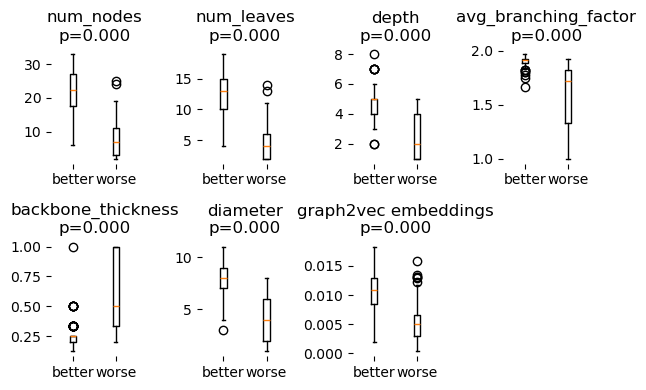

In [78]:
# QUARTILES DIFFERENT
q12_flow_trees = []
q34_flow_trees = []

for (start_node, end_node, quartile), group in test_df.groupby(["StartAt", "EndAt", "quartile"]):
    trajs = np.array(group["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    
    # for embeddings to work
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')

    if quartile <= 2:
        q12_flow_trees.append(new_G)
    else:
        q34_flow_trees.append(new_G)

results_df = get_new_results_df()

# Run comparison on quartile groups
results_df, q12_features, q34_features = compare_flow_tree_groups(
    results_df,
    q12_flow_trees, 
    q34_flow_trees,
    group1_name="quartiles 1-2",
    group2_name="quartiles 3-4",
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis="Flow Trees of top-half performers are different from those of bottom-half ones."
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(6, 4))
for i, feature_name in enumerate(results_df['metric'].unique()):
    feature_results = results_df[results_df['metric'] == feature_name]
    perm_result = feature_results[feature_results['test_type'] == 'permutation'].iloc[0]
    
    plt.subplot(2, 4, i+1)
    plt.boxplot([q12_features[:, i], q34_features[:, i]], 
                labels=['better', 'worse'])
    plt.title(f'{feature_name}\np={perm_result["p_value"]:.3f}')
    # if perm_result["significant"]:
        # plt.gca().set_facecolor('lightgreen')
    plt.box(on=None)
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)


In [ ]:
all_results_df

,hypothesis,test_type,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,significant,metric,notes
0,Flow Trees of top-half performers are differen...,t-test,quartiles 1-2,quartiles 3-4,0.643369,0.185932,0.039120,0.025306,144,144,21.551077,7.346237e-62,True,depth,Comparing flow tree depth between quartiles 1-...
1,Flow Trees of top-half performers are differen...,permutation,quartiles 1-2,quartiles 3-4,0.643369,0.185932,0.039120,0.025306,144,144,0.457437,2.000000e-04,True,depth,Permutation test on flow tree depth between qu...
2,Flow Trees of top-half performers are differen...,t-test,quartiles 1-2,quartiles 3-4,0.533730,0.208333,0.022672,0.033411,144,144,16.431053,3.512330e-43,True,diameter,Comparing flow tree diameter between quartiles...
3,Flow Trees of top-half performers are differen...,permutation,quartiles 1-2,quartiles 3-4,0.533730,0.208333,0.022672,0.033411,144,144,0.325397,2.000000e-04,True,diameter,Permutation test on flow tree diameter between...
4,Flow Trees of top-half performers are differen...,t-test,quartiles 1-2,quartiles 3-4,0.693750,0.293750,0.025586,0.037947,144,144,18.977036,1.527278e-52,True,num_leaves,Comparing flow tree num_leaves between quartil...
5,Flow Trees of top-half performers are differen...,permutation,quartiles 1-2,quartiles 3-4,0.693750,0.293750,0.025586,0.037947,144,144,0.400000,2.000000e-04,True,num_leaves,Permutation test on flow tree num_leaves betwe...
6,Flow Trees of top-half performers are differen...,t-test,quartiles 1-2,quartiles 3-4,0.606618,0.150735,0.039238,0.023055,144,144,21.842485,6.700919e-63,True,avg_branching_factor,Comparing flow tree avg_branching_factor betwe...
7,Flow Trees of top-half performers are differen...,permutation,quartiles 1-2,quartiles 3-4,0.606618,0.150735,0.039238,0.023055,144,144,0.455882,2.000000e-04,True,avg_branching_factor,Permutation test on flow tree avg_branching_fa...
8,Flow Trees of top-half performers are differen...,t-test,quartiles 1-2,quartiles 3-4,0.931293,0.625462,0.001719,0.076657,144,144,13.063424,6.669861e-31,True,backbone_thickness,Comparing flow tree backbone_thickness between...
9,Flow Trees of top-half performers are differen...,permutation,quartiles 1-2,quartiles 3-4,0.931293,0.625462,0.001719,0.076657,144,144,0.305831,2.000000e-04,True,backbone_thickness,Permutation test on flow tree backbone_thickne...


KeyboardInterrupt: 

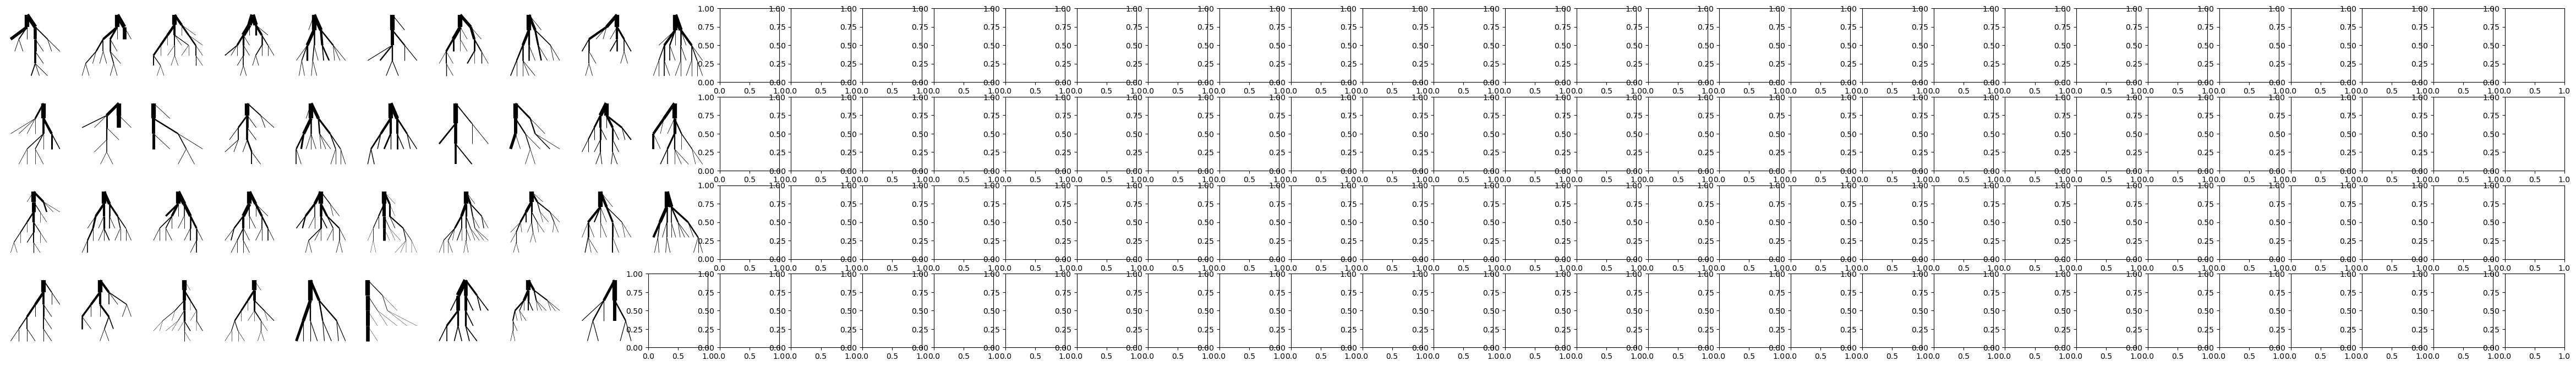

In [65]:
fig, axes = plt.subplots(4, 36, figsize=(60,8))

for i, G in enumerate(q12_flow_trees):
    
    # Convert from i to column-major indices
    col = i // 4
    row = i % 4
    ax = axes[row][col]
    plot_flow_tree(G, f"", ax, no_title=True, just_edges=True)

# fig.suptitle("Test-path trees sorted by subject-mean path accuracy")
# fig.savefig("figures/test_flow_trees_by_acc.png")

plt.show()

fig, axes = plt.subplots(4, 36, figsize=(60,8))

for i, G in enumerate(q34_flow_trees):
    
    # Convert from i to column-major indices
    col = i // 4
    row = i % 4
    ax = axes[row][col]
    plot_flow_tree(G, f"", ax, no_title=True, just_edges=True)

# fig.suptitle("Test-path trees sorted by subject-mean path accuracy")
# fig.savefig("figures/test_flow_trees_by_acc.png")

plt.show()


Hypothesis Test Results:
                                                                        hypothesis    test_type group1_name group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n  statistic       p_value  significant                metric                                                                     notes
0   Flow Trees of successful males are different from those of successful females.       t-test         men       women     4.564912     5.757895    4.814207    6.085245       285       285  -6.089630  2.085815e-09         True             num_nodes                       Comparing flow tree num_nodes between men and women
1   Flow Trees of successful males are different from those of successful females.  permutation         men       women     4.564912     5.757895    4.814207    6.085245       285       285   1.192982  2.000000e-04         True             num_nodes             Permutation test on flow tree num_nodes between men and women
2 

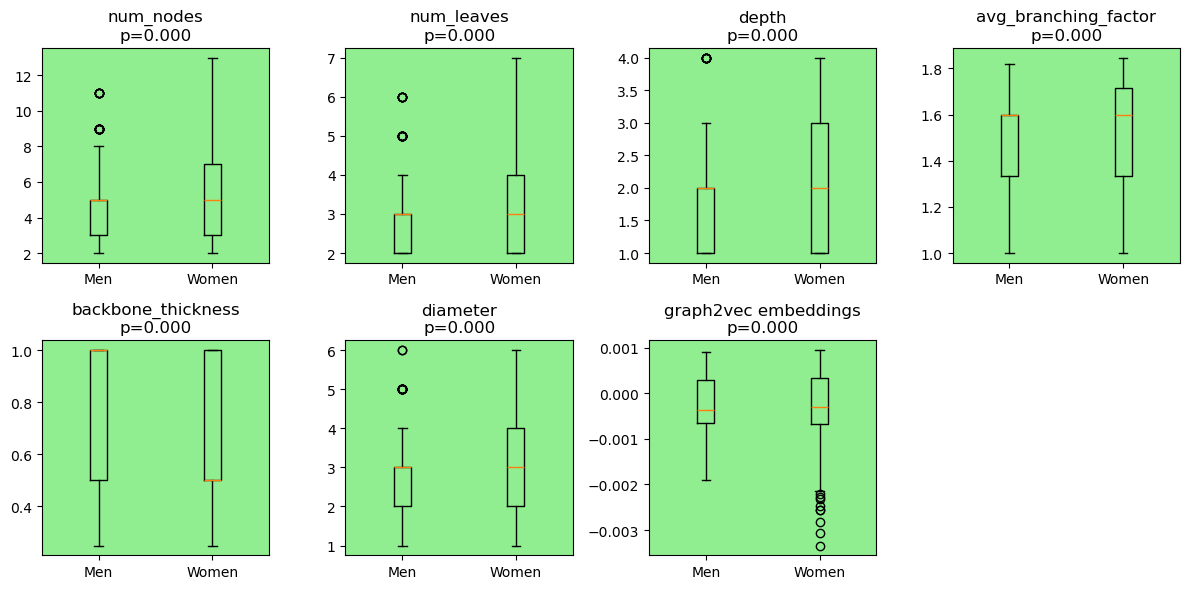

In [79]:
# MEN V WOMEN DIFFERENT
men_flow_trees = []
women_flow_trees = []

min = 99

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    group = group[group["accuracy"]]
    
    men_df = group[group["is_man"]]
    women_df = group[~group["is_man"]]

    min_num_trajs = np.min([women_df.shape[0], men_df.shape[0]])
    if min_num_trajs < 10: continue

    for i in range(5):
        sample_df1 = men_df.sample(n=10, random_state=i) 
        sample_df2 = women_df.sample(n=10, random_state=i) 

        trajs1 = np.array(sample_df1["trajs"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE="0")
        new_G1 = nx.relabel.convert_node_labels_to_integers(G1, first_label=0, ordering='default')

        trajs2 = np.array(sample_df2["trajs"])
        G2 = generate_flow_tree_from_trajs(trajs2, END_NODE="0")
        new_G2 = nx.relabel.convert_node_labels_to_integers(G2, first_label=0, ordering='default')

        men_flow_trees.append(new_G1)
        women_flow_trees.append(new_G2)

results_df = get_new_results_df()

# Run comparison on sex groups
results_df, men_features, women_features = compare_flow_tree_groups(
    results_df,
    men_flow_trees, 
    women_flow_trees,
    group1_name="men",
    group2_name="women",
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis="Flow Trees of successful males are different from those of successful females."
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(12, 6))
for i, feature_name in enumerate(results_df['metric'].unique()):
    feature_results = results_df[results_df['metric'] == feature_name]
    perm_result = feature_results[feature_results['test_type'] == 'permutation'].iloc[0]
    
    plt.subplot(2, 4, i+1)
    plt.boxplot([men_features[:, i], women_features[:, i]], 
                labels=['Men', 'Women'])
    plt.title(f'{feature_name}\np={perm_result["p_value"]:.3f}')
    if perm_result["significant"]:
        plt.gca().set_facecolor('lightgreen')
    
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)

### Inner nodes v outer nodes

In [80]:
# PATHS STARTING FROM OUTER NODES
outer_starting_flow_trees = []
inner_starting_flow_trees = []

outer_ending_flow_trees = []
inner_ending_flow_trees = []

min = 99
OUTER_NODES = "NALPWY"

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    group = group[group["accuracy"]]

    if len(group) < 10: continue

    for i in range(5):
        sample_df1 = group.sample(n=10, random_state=i) 

        trajs1 = np.array(sample_df1["trajs"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE="0")
        new_G1 = nx.relabel.convert_node_labels_to_integers(G1, first_label=0, ordering='default')
        
        if start_node in OUTER_NODES:
            outer_starting_flow_trees.append(new_G1)
        else:
            inner_starting_flow_trees.append(new_G1)

        if end_node in OUTER_NODES:
            outer_ending_flow_trees.append(new_G1)
        else:
            inner_ending_flow_trees.append(new_G1)


Hypothesis Test Results:
                                                                                      hypothesis    test_type     group1_name     group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n  statistic   p_value  significant                metric                                                                                         notes
0   Flow Trees for paths starting from outside nodes are different from those from inside nodes.       t-test  outer_starting  inner_starting     5.483333     4.616667    6.441389    3.503056       240       120   3.307606  0.001036         True             num_nodes                       Comparing flow tree num_nodes between outer_starting and inner_starting
1   Flow Trees for paths starting from outside nodes are different from those from inside nodes.  permutation  outer_starting  inner_starting     5.483333     4.616667    6.441389    3.503056       240       120   0.866667  0.002000         True     

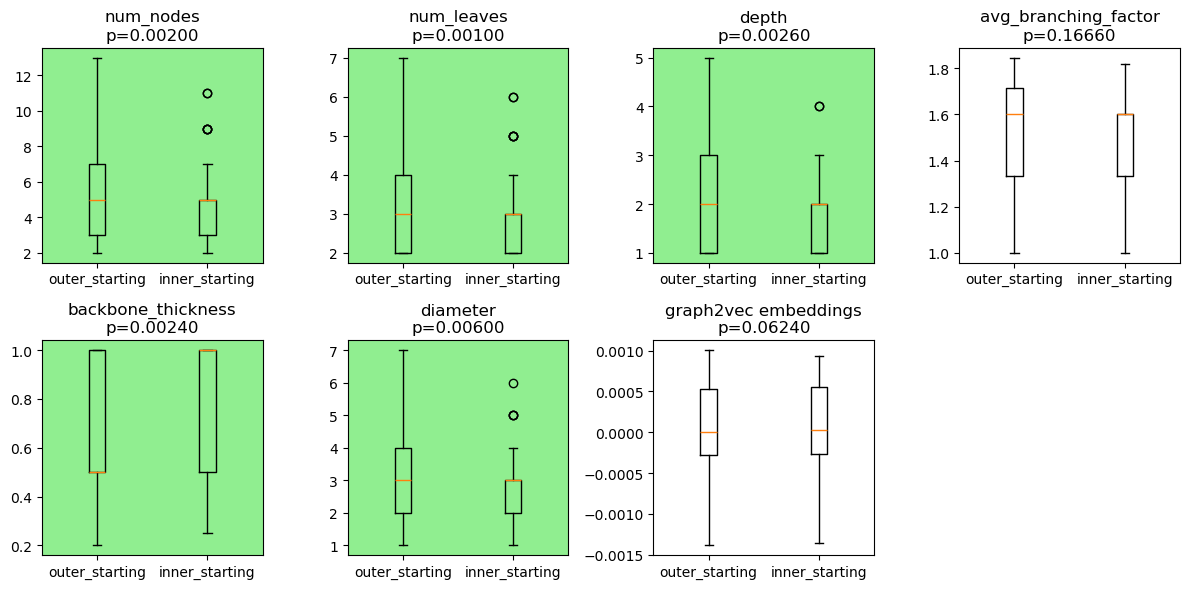

In [81]:
results_df = get_new_results_df()

# Run comparison on inner v outer starting
results_df, outer_starting_features, inner_starting_features = compare_flow_tree_groups(
    results_df,
    outer_starting_flow_trees, 
    inner_starting_flow_trees,
    group1_name="outer_starting",
    group2_name="inner_starting",
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis="Flow Trees for paths starting from outside nodes are different from those from inside nodes."
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(12, 6))
for i, feature_name in enumerate(results_df['metric'].unique()):
    feature_results = results_df[results_df['metric'] == feature_name]
    perm_result = feature_results[feature_results['test_type'] == 'permutation'].iloc[0]
    
    plt.subplot(2, 4, i+1)
    plt.boxplot([outer_starting_features[:, i], inner_starting_features[:, i]], 
                labels=['outer_starting', 'inner_starting'])
    plt.title(f'{feature_name}\np={perm_result["p_value"]:.5f}')
    if perm_result["significant"]:
        plt.gca().set_facecolor('lightgreen')
    
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)


Hypothesis Test Results:
                                                                                hypothesis    test_type   group1_name   group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n  statistic   p_value  significant                metric                                                                                     notes
0   Flow Trees for paths ending at outside nodes are different from those at inside nodes.       t-test  outer_ending  inner_ending     5.108333     5.366667    5.846597    5.148889       240       120  -0.972475  0.331471        False             num_nodes                       Comparing flow tree num_nodes between outer_ending and inner_ending
1   Flow Trees for paths ending at outside nodes are different from those at inside nodes.  permutation  outer_ending  inner_ending     5.108333     5.366667    5.846597    5.148889       240       120   0.258333  0.680400        False             num_nodes             Permutat

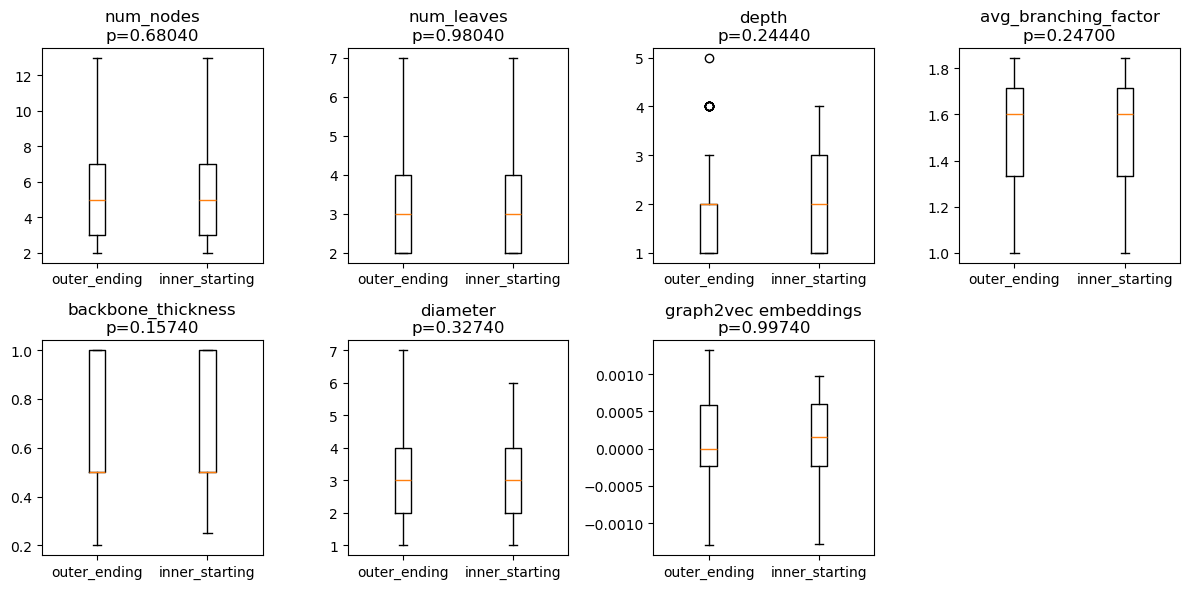

In [82]:
results_df = get_new_results_df()

# Run comparison on inner v outer ending
results_df, outer_ending_features, inner_ending_features = compare_flow_tree_groups(
    results_df,
    outer_ending_flow_trees, 
    inner_ending_flow_trees,
    group1_name="outer_ending",
    group2_name="inner_ending",
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis="Flow Trees for paths ending at outside nodes are different from those at inside nodes."
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(12, 6))
for i, feature_name in enumerate(results_df['metric'].unique()):
    feature_results = results_df[results_df['metric'] == feature_name]
    perm_result = feature_results[feature_results['test_type'] == 'permutation'].iloc[0]
    
    plt.subplot(2, 4, i+1)
    plt.boxplot([outer_ending_features[:, i], inner_ending_features[:, i]], 
                labels=['outer_ending', 'inner_starting'])
    plt.title(f'{feature_name}\np={perm_result["p_value"]:.5f}')
    if perm_result["significant"]:
        plt.gca().set_facecolor('lightgreen')
    
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)

### In same as out?

In [83]:
# Function to generate bootstrapped trees
def generate_bootstrap_trees(group, k_fold=20, sample_frac=0.7, sample_size=20, reverse_trajs=False):
    trees = []
    for _ in range(k_fold):
        sampled_group = group.sample(frac=sample_frac)
        # Randomly select sample_size samples if group is larger than that
        if len(sampled_group) > sample_size:
            sampled_group = sampled_group.sample(n=sample_size)
        trajs = generate_trajs_from_df(sampled_group)
        if reverse_trajs:
            trajs = [list(reversed(t)) for t in trajs]
        G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
    return trees

# Create empty DataFrame to store all tree information
tree_df = pd.DataFrame(columns=[
    'node_type',      # 'start' or 'end'
    'node',           # the actual node label
    'trajectory_type', # 'all', 'winner', or 'loser'
    'mean_accuracy',   # mean accuracy for this group
    'trees'           # list of bootstrapped trees
])

# Generate trees for start nodes
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['accuracy']]),
    ('loser', test_df[~test_df['accuracy']])
]:
    for (start_node,), group in df_subset.groupby(['StartAt']):
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group)
        
        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['start'] * len(trees),
            'node': [start_node] * len(trees), 
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)

# Generate trees for end nodes
test_df['ending_node'] = test_df['paths'].apply(lambda x: x[-1])
for traj_type, df_subset in [
    ('all', test_df),
    ('winner', test_df[test_df['ending_node'] == test_df['EndAt']]),
    ('loser', test_df[test_df['ending_node'] != test_df['EndAt']])
]:
    for (end_node,), group in df_subset.groupby(['ending_node']):
        if end_node[0] not in OBJECTS:
            continue
        mean_acc = np.mean(group['path_mean_acc'])
        trees = generate_bootstrap_trees(group, reverse_trajs=True)
        
        tree_df = pd.concat([tree_df, pd.DataFrame({
            'node_type': ['end'] * len(trees),
            'node': [end_node] * len(trees),
            'trajectory_type': [traj_type] * len(trees),
            'mean_accuracy': [mean_acc] * len(trees),
            'trees': trees
        })], ignore_index=True)


Hypothesis Test Results:
                                                               hypothesis    test_type       group1_name       group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n  statistic       p_value  significant                metric                                                                                             notes
0   Flow out of outside nodes is different from flow out of inside nodes.       t-test  outer_start_node  inner_start_node    25.333333    25.777778   18.083333   31.617284       360       180  -1.022350  3.070748e-01        False             num_nodes                       Comparing flow tree num_nodes between outer_start_node and inner_start_node
1   Flow out of outside nodes is different from flow out of inside nodes.  permutation  outer_start_node  inner_start_node    25.333333    25.777778   18.083333   31.617284       360       180   0.444444  6.206000e-01        False             num_nodes             Permuta

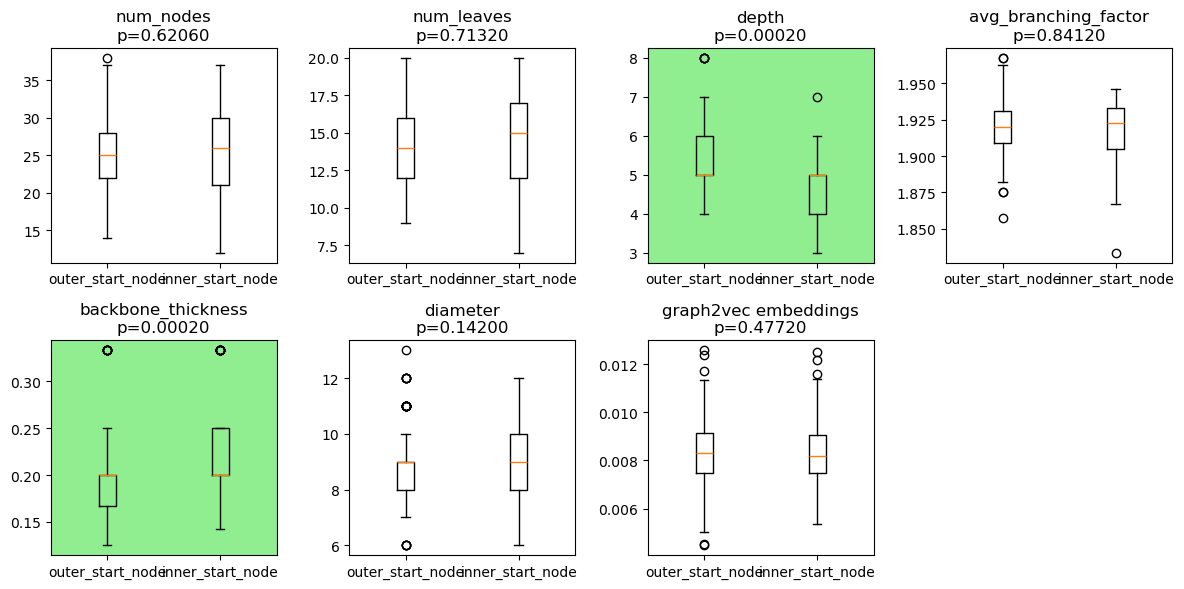

In [84]:
results_df = get_new_results_df()

outer_start_node_flow_trees = tree_df[(tree_df['node_type'] == "start") & tree_df['node'].apply(lambda x: x in OUTER_NODES)]['trees'].tolist()
inner_start_node_flow_trees = tree_df[(tree_df['node_type'] == "start") & ~tree_df['node'].apply(lambda x: x in OUTER_NODES)]['trees'].tolist()

# Run comparison on inner v outer ending
results_df, outer_start_node_features, inner_start_node_features = compare_flow_tree_groups(
    results_df,
    outer_start_node_flow_trees, 
    inner_start_node_flow_trees,
    group1_name="outer_start_node",
    group2_name="inner_start_node",
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis="Flow out of outside nodes is different from flow out of inside nodes."
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(12, 6))
for i, feature_name in enumerate(results_df['metric'].unique()):
    feature_results = results_df[results_df['metric'] == feature_name]
    perm_result = feature_results[feature_results['test_type'] == 'permutation'].iloc[0]
    
    plt.subplot(2, 4, i+1)
    plt.boxplot([outer_start_node_features[:, i], inner_start_node_features[:, i]], 
                labels=['outer_start_node', 'inner_start_node'])
    plt.title(f'{feature_name}\np={perm_result["p_value"]:.5f}')
    if perm_result["significant"]:
        plt.gca().set_facecolor('lightgreen')
    
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)


Hypothesis Test Results:
                                                           hypothesis    test_type     group1_name     group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n  statistic       p_value  significant                metric                                                                                         notes
0   Flow into outside nodes is different from flow into inside nodes.       t-test  outer_end_node  inner_end_node    20.269444    22.266667    9.574622   11.784444       360       180  -6.800738  2.776893e-11         True             num_nodes                       Comparing flow tree num_nodes between outer_end_node and inner_end_node
1   Flow into outside nodes is different from flow into inside nodes.  permutation  outer_end_node  inner_end_node    20.269444    22.266667    9.574622   11.784444       360       180   1.997222  2.000000e-04         True             num_nodes             Permutation test on flow tree num_nodes

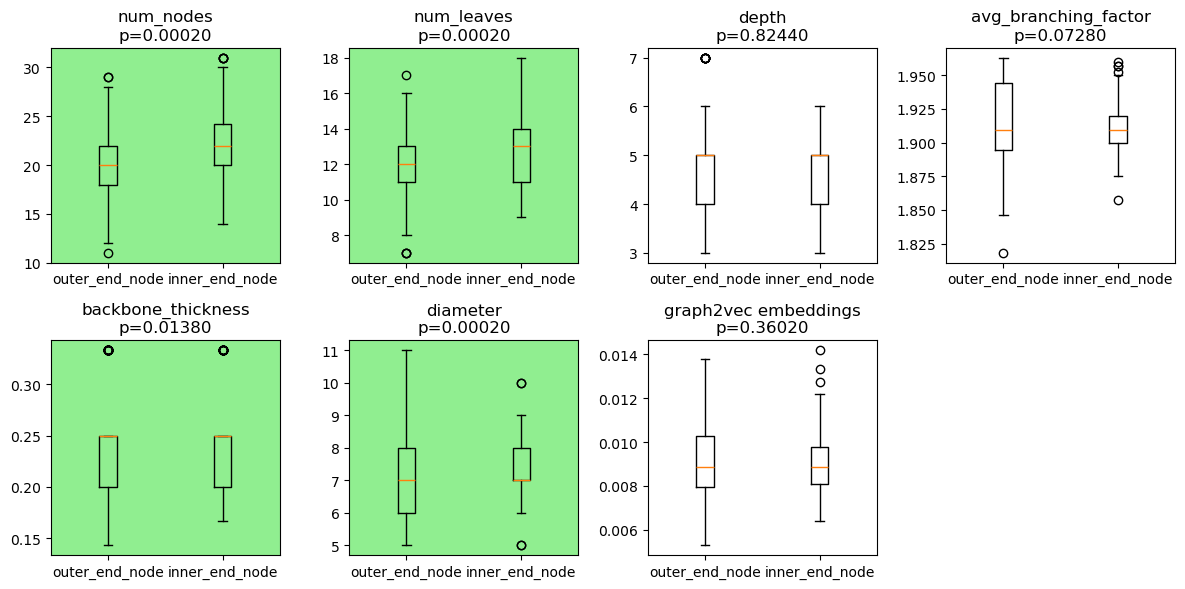

In [85]:
results_df = get_new_results_df()

outer_end_node_flow_trees = tree_df[(tree_df['node_type'] == "end") & tree_df['node'].apply(lambda x: x in OUTER_NODES)]['trees'].tolist()
inner_end_node_flow_trees = tree_df[(tree_df['node_type'] == "end") & ~tree_df['node'].apply(lambda x: x in OUTER_NODES)]['trees'].tolist()

# Run comparison on inner v outer ending
results_df, outer_end_node_features, inner_end_node_features = compare_flow_tree_groups(
    results_df,
    outer_end_node_flow_trees, 
    inner_end_node_flow_trees,
    group1_name="outer_end_node",
    group2_name="inner_end_node",
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis="Flow into outside nodes is different from flow into inside nodes."
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(12, 6))
for i, feature_name in enumerate(results_df['metric'].unique()):
    feature_results = results_df[results_df['metric'] == feature_name]
    perm_result = feature_results[feature_results['test_type'] == 'permutation'].iloc[0]
    
    plt.subplot(2, 4, i+1)
    plt.boxplot([outer_end_node_features[:, i], inner_end_node_features[:, i]], 
                labels=['outer_end_node', 'inner_end_node'])
    plt.title(f'{feature_name}\np={perm_result["p_value"]:.5f}')
    if perm_result["significant"]:
        plt.gca().set_facecolor('lightgreen')
    
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)

### Flow in v flow out


Hypothesis Test Results:
                                               hypothesis    test_type group1_name group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n  statistic        p_value  significant                metric                                                                                 notes
0   Start Flow Trees are different from reverse end ones.       t-test  start node  start node    25.481481    20.935185   22.638546   11.197651       540       540  18.145183   2.039111e-64         True             num_nodes                       Comparing flow tree num_nodes between start node and start node
1   Start Flow Trees are different from reverse end ones.  permutation  start node  start node    25.481481    20.935185   22.638546   11.197651       540       540   4.546296   2.000000e-04         True             num_nodes             Permutation test on flow tree num_nodes between start node and start node
2   Start Flow Trees are different fro

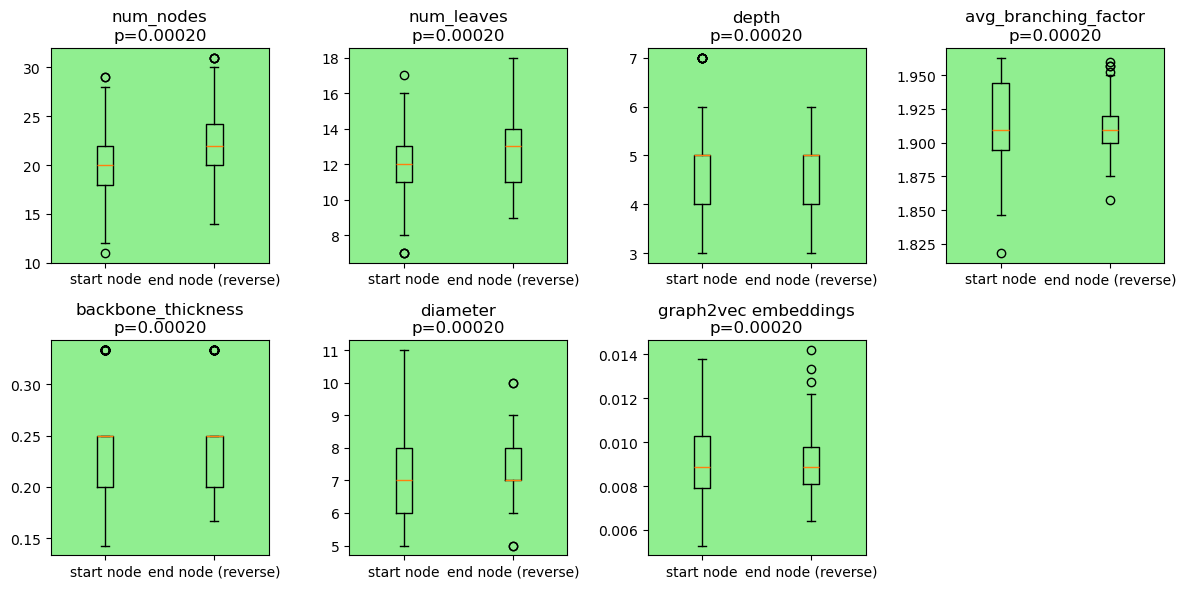

In [86]:
results_df = get_new_results_df()

hypothesis_str = "Start Flow Trees are different from reverse end ones."
group1_name, group2_name = "start node", "end node (reverse)"
group1_flow_trees = tree_df[(tree_df['node_type'] == "start")]['trees'].tolist()
group2_flow_trees = tree_df[(tree_df['node_type'] == "end")]['trees'].tolist()

# Run comparison on inner v outer ending
results_df, group1_features, group2_features = compare_flow_tree_groups(
    results_df,
    group1_flow_trees, 
    group2_flow_trees,
    group1_name=group1_name,
    group2_name=group1_name,
    # normalise=True,
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis=hypothesis_str
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(12, 6))
for i, feature_name in enumerate(results_df['metric'].unique()):
    feature_results = results_df[results_df['metric'] == feature_name]
    perm_result = feature_results[feature_results['test_type'] == 'permutation'].iloc[0]
    
    plt.subplot(2, 4, i+1)
    plt.boxplot([outer_end_node_features[:, i], inner_end_node_features[:, i]], 
                labels=[group1_name, group2_name])
    plt.title(f'{feature_name}\np={perm_result["p_value"]:.5f}')
    if perm_result["significant"]:
        plt.gca().set_facecolor('lightgreen')
    
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)

In [87]:
results_df = get_new_results_df()

node_of_interest = "N"
for node_of_interest in OBJECTS:
    hypothesis_str = f"Does flow into {node_of_interest} look like flow out of {node_of_interest}?"
    group1_name, group2_name = f"flow out of {node_of_interest}", f"flow into {node_of_interest}"
    group1_flow_trees = tree_df[(tree_df['node_type'] == "start") & (tree_df['node'] == node_of_interest)]['trees'].tolist()
    group2_flow_trees = tree_df[(tree_df['node_type'] == "end") & (tree_df['node'] == node_of_interest)]['trees'].tolist()

    # Run comparison on inner v outer ending
    results_df, group1_features, group2_features = compare_flow_tree_groups(
        results_df,
        group1_flow_trees, 
        group2_flow_trees,
        group1_name=group1_name,
        group2_name=group1_name,
        normalise=False,
        hypothesis_test_types=["t-test", "permutation"],
        hypothesis=hypothesis_str
    )

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(12, 6))
for i, feature_name in enumerate(results_df['metric'].unique()):
    feature_results = results_df[results_df['metric'] == feature_name]
    perm_result = feature_results[feature_results['test_type'] == 'permutation'].iloc[0]
    
    plt.subplot(2, 3, i+1)
    plt.boxplot([outer_end_node_features[:, i], inner_end_node_features[:, i]], 
                labels=[group1_name, group2_name])
    plt.title(f'{feature_name}\np={perm_result["p_value"]:.5f}')
    if perm_result["significant"]:
        plt.gca().set_facecolor('lightgreen')
    
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)

KeyboardInterrupt: 

### Foils? Compare start nodes against all others

In [26]:
K_FOLD = 20

start_tree_dict = {}
for start_node, group in test_df[test_df["accuracy"]].groupby(["StartAt"]):
    trees = []
    mean_acc = np.mean(group["path_mean_acc"])
    
    # Generate K_FOLD bootstrapped trees
    for _ in range(K_FOLD):
        # Sample 70% of trajectories
        sampled_group = group.sample(frac=0.7)
        trajs = generate_trajs_from_df(sampled_group)
        G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
        
        # Convert node labels to integers
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
        
    start_tree_dict[start_node] = [trees, mean_acc]

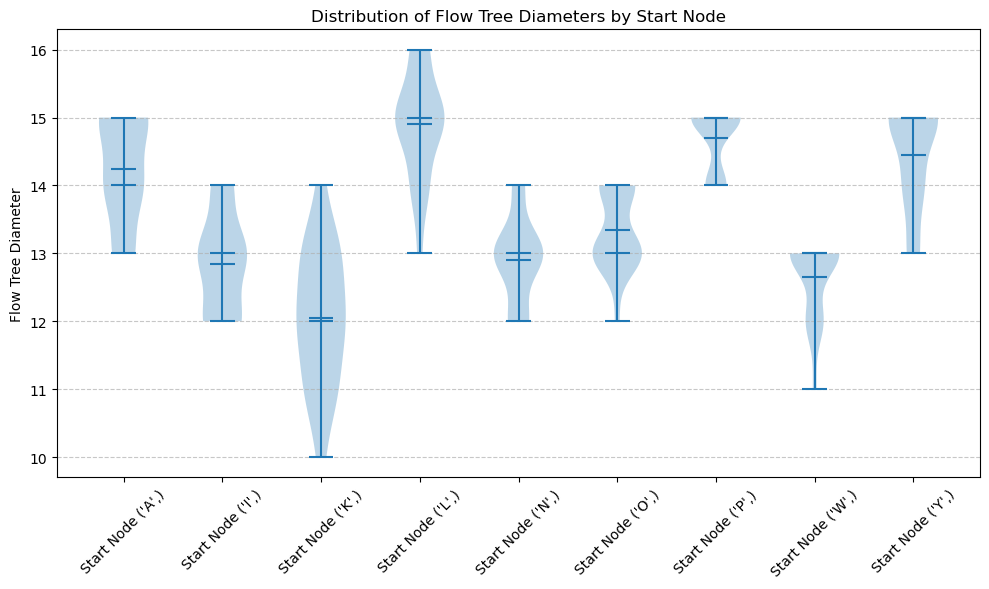

In [27]:
# Plot distributions of Flow Tree diameters for each start node
plt.figure(figsize=(10, 6))

diameters = []
labels = []
for start_node, (trees, _) in start_tree_dict.items():
    # Calculate diameters for all trees from this start node
    node_diameters = [nx.diameter(tree) for tree in trees]
    diameters.append(node_diameters)
    labels.append(f"Start Node {start_node}")

# Create violin plot
plt.violinplot(diameters, showmeans=True, showmedians=True)
plt.xticks(range(1, len(labels) + 1), labels, rotation=45)
plt.ylabel("Flow Tree Diameter")
plt.title("Distribution of Flow Tree Diameters by Start Node")

# Add grid for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [28]:
print("Do Flow Trees from different starting nodes have different diameters?")

# Get all unique start nodes
start_nodes = list(start_tree_dict.keys())

test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)

# Combine all trees for fitting
all_trees = []
for trees, _ in start_tree_dict.values():
    all_trees.extend(trees)
test_flow_tree_embedder.fit(all_trees)

print("\nSummary of Flow Tree Diameter Comparisons (Bonferroni corrected):")
print("------------------------------------------")
n_comparisons = (len(start_nodes) * (len(start_nodes) - 1)) // 2  # Number of pairwise comparisons
alpha = 0.05 / n_comparisons  # Bonferroni correction

# Keep track of percentage diff (ie, p < 0.001)
from collections import defaultdict
percent_diff_dict = {}
for i in range(len(start_nodes)):
    tally = []
    temp_results_df = pd.DataFrame(columns=[
            'hypothesis',
            'test_type',
            'group1_name',
            'group2_name',
            'group1_mean',
            'group2_mean',
            'group1_var',
            'group2_var',
            'group1_n',
            'group2_n',
            'statistic',
            'p_value',
            'significant',
            'metric',
            'notes'
        ])
    
    node1 = start_nodes[i]
    for j in range(len(start_nodes)):
        if i == j: continue
         
        node2 = start_nodes[j]

        temp_results_df, men_features, women_features = compare_flow_tree_groups(
            temp_results_df,
            start_tree_dict[node1][0], 
            start_tree_dict[node2][0],
            group1_name=f"starting {node1}",
            group2_name=f"starting {node2}",
            hypothesis_test_types=["permutation"], #["t-test", "permutation"],
            hypothesis=f"Are group dynamics different leaving from {node1} v {node2}?"
        )

        # print(temp_results_df)
        
        # group1 = np.array([nx.diameter(FT) for FT in start_tree_dict[node1][0]])
        # group2 = np.array([nx.diameter(FT) for FT in start_tree_dict[node2][0]])
        
        # # Run t-test
        # t_stat, p_val = stats.ttest_ind(group1, group2)
        
    # Calculate percentage of significant results for each metric
    metrics = temp_results_df['metric'].unique()
    for metric in metrics:
        metric_results = temp_results_df[temp_results_df['metric'] == metric]
        print(node1, metric)
        print(metric_results['p_value'])
        significant_count = (metric_results['p_value'] < alpha).sum()
        total_count = len(metric_results)
        if total_count > 0:  # Avoid division by zero
            significant_percentage = significant_count / total_count
            if node1 not in percent_diff_dict:
                percent_diff_dict[node1] = {}
            if metric not in percent_diff_dict[node1]:
                percent_diff_dict[node1][metric] = []
            percent_diff_dict[node1][metric].append(significant_percentage)
            
            # result = "different" if significant_percentage > 0 else "the same"
            # print(f"{node1} vs {node2} - {metric}: {result} ({significant_percentage*100:.1f}% significant, threshold={alpha:.3f})")
print(percent_diff_dict)    


Do Flow Trees from different starting nodes have different diameters?

Summary of Flow Tree Diameter Comparisons (Bonferroni corrected):
------------------------------------------
('A',) depth
0     0.0002
6     0.0002
12    0.0002
18    0.0002
24    0.0002
30    0.0098
36    0.0816
42    0.0002
Name: p_value, dtype: float64
('A',) diameter
1     0.0002
7     0.0002
13    0.0028
19    0.0002
25    0.0002
31    0.8980
37    0.0002
43    0.0002
Name: p_value, dtype: float64
('A',) num_leaves
2     0.0002
8     0.0002
14    0.0210
20    0.0002
26    0.0006
32    0.1260
38    0.0002
44    1.0718
Name: p_value, dtype: float64
('A',) avg_branching_factor
3     0.0002
9     0.0002
15    0.0002
21    0.0002
27    0.0002
33    0.2568
39    0.2074
45    0.0002
Name: p_value, dtype: float64
('A',) backbone_thickness
4     0.0002
10    0.0002
16    0.0002
22    0.0002
28    0.0002
34    0.0088
40    0.0624
46    0.0002
Name: p_value, dtype: float64
('A',) graph2vec embeddings
5     0.0002
11    0.

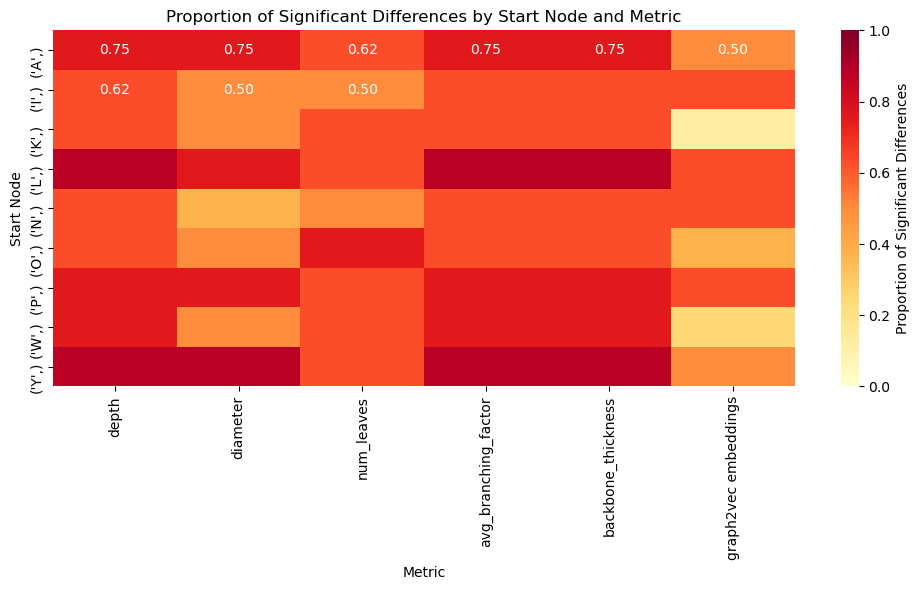

In [29]:
# Convert the nested dictionary to a DataFrame for heatmap visualization
metrics_list = list(next(iter(percent_diff_dict.values())).keys())
nodes_list = list(percent_diff_dict.keys())

heatmap_data = []
for node in nodes_list:
    row = []
    for metric in metrics_list:
        # Calculate average percentage for this node-metric combination
        avg_percentage = np.mean(percent_diff_dict[node][metric])
        row.append(avg_percentage)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, 
                         index=nodes_list,
                         columns=metrics_list)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, 
            annot=True,  # Show values in cells
            fmt='.2f',   # Format as 2 decimal places
            cmap='YlOrRd',  # Yellow to Red colormap
            vmin=0, 
            vmax=1,
            cbar_kws={'label': 'Proportion of Significant Differences'})

plt.title('Proportion of Significant Differences by Start Node and Metric')
plt.ylabel('Start Node')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()


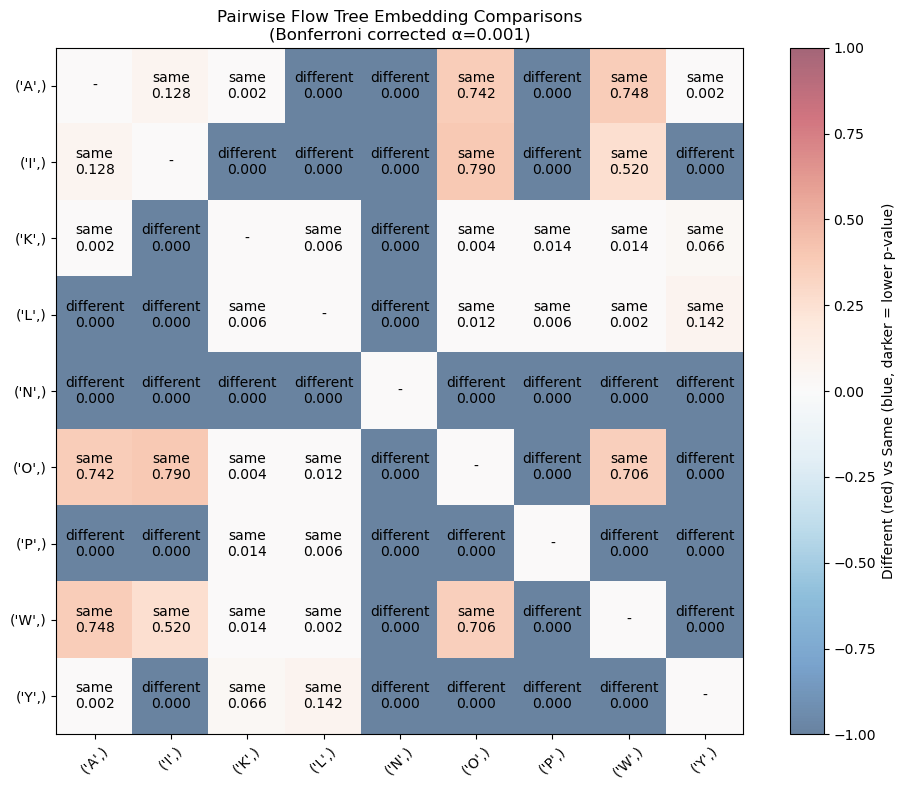

In [30]:

# print("\nSummary of Flow Tree Embedding Comparisons (Bonferroni corrected):") 
# print("-------------------------------------------")
# for i in range(len(start_nodes)):
#     for j in range(i+1, len(start_nodes)):
#         node1 = start_nodes[i]
#         node2 = start_nodes[j]
        
#         embeddings1 = test_flow_tree_embedder.infer(start_tree_dict[node1][0])
#         embeddings2 = test_flow_tree_embedder.infer(start_tree_dict[node2][0])
        
#         # Calculate distances within and between groups
#         dist1 = pdist(embeddings1)
#         dist2 = pdist(embeddings2)
#         dist_between = pdist(np.vstack([embeddings1, embeddings2]))
        
#         # Calculate test statistic and p-value
#         observed = np.mean(dist_between) - (np.mean(dist1) + np.mean(dist2))/2
        
#         # Get p-value from previous test
#         n_perms = 500
#         count = 0
#         for _ in range(n_perms):
#             combined = np.vstack([embeddings1, embeddings2])
#             np.random.shuffle(combined)
#             perm1 = combined[:len(embeddings1)]
#             perm2 = combined[len(embeddings1):]
            
#             dist1_perm = pdist(perm1)
#             dist2_perm = pdist(perm2)
#             dist_between_perm = pdist(combined)
            
#             perm_stat = np.mean(dist_between_perm) - (np.mean(dist1_perm) + np.mean(dist2_perm))/2
#             if abs(perm_stat) >= abs(observed):
#                 count += 1
                
#         p_val = count/n_perms
        
#         result = "different" if p_val < alpha else "the same"
#         print(f"{node1} vs {node2}: {result} (p={p_val:.3f}, corrected threshold={alpha:.3f})")

# Create a matrix to store p-values
n_nodes = len(start_nodes)
p_value_matrix = np.zeros((n_nodes, n_nodes))
significance_matrix = np.zeros((n_nodes, n_nodes))

# Fill matrices
for i in range(len(start_nodes)):
    for j in range(len(start_nodes)):
        if i < j:
            node1 = start_nodes[i]
            node2 = start_nodes[j]
            
            embeddings1 = test_flow_tree_embedder.infer(start_tree_dict[node1][0]) # 0 index is trees, 1 is acc
            embeddings2 = test_flow_tree_embedder.infer(start_tree_dict[node2][0])
            
            # Calculate distances within and between groups
            dist1 = pdist(embeddings1)
            dist2 = pdist(embeddings2)
            dist_between = pdist(np.vstack([embeddings1, embeddings2]))
            
            # Calculate test statistic
            observed = np.mean(dist_between) - (np.mean(dist1) + np.mean(dist2))/2
            
            # Get p-value from permutation test
            n_perms = 500
            count = 0
            for _ in range(n_perms):
                combined = np.vstack([embeddings1, embeddings2])
                np.random.shuffle(combined)
                perm1 = combined[:len(embeddings1)]
                perm2 = combined[len(embeddings1):]
                
                dist1_perm = pdist(perm1)
                dist2_perm = pdist(perm2)
                dist_between_perm = pdist(combined)
                
                perm_stat = np.mean(dist_between_perm) - (np.mean(dist1_perm) + np.mean(dist2_perm))/2
                if abs(perm_stat) >= abs(observed):
                    count += 1
            
            p_val = count/n_perms
            p_value_matrix[i,j] = p_val
            p_value_matrix[j,i] = p_val
            significance_matrix[i,j] = p_val < alpha  # Using Bonferroni corrected threshold
            significance_matrix[j,i] = p_val < alpha
# Plot heatmap
plt.figure(figsize=(10,8))

# Create custom color matrix based on p-values and significance
color_matrix = np.zeros_like(significance_matrix, dtype=float)
for i in range(n_nodes):
    for j in range(n_nodes):
        if significance_matrix[i,j]:  # Different - use blue
            color_matrix[i,j] = -1
        else:  # Same - use red with gradient based on p-value
            color_matrix[i,j] = p_value_matrix[i,j] * 0.5  # Scale down red intensity

plt.imshow(color_matrix, cmap='RdBu_r', vmin=-1, vmax=1, alpha=0.6)  # Add transparency
plt.colorbar(label='Different (red) vs Same (blue, darker = lower p-value)')

# Add text annotations
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            text = 'different' if significance_matrix[i,j] else 'same'
            plt.text(j, i, f'{text}\n{p_value_matrix[i,j]:.3f}', 
                    ha='center', va='center')
        else:
            plt.text(j, i, '-', ha='center', va='center')

plt.xticks(range(n_nodes), start_nodes, rotation=45)
plt.yticks(range(n_nodes), start_nodes)
plt.title('Pairwise Flow Tree Embedding Comparisons\n(Bonferroni corrected α={:.3f})'.format(alpha))
plt.tight_layout()
plt.show()


## 4. Summarise results

In [59]:
# all_results_df
all_results_df['hypothesis'].unique()

array(['Flow Trees of top-half performers are different from those of bottom-half ones.',
       'Flow Trees of successful males are different from those of successful females.',
       'Flow Trees for paths starting from outside nodes are different from those from inside nodes.',
       'Flow Trees for paths ending at outside nodes are different from those at inside nodes.',
       'Flow out of outside nodes is different from flow out of inside nodes.',
       'Flow into outside nodes is different from flow into inside nodes.',
       'Start Flow Trees are different from reverse end ones.'],
      dtype=object)

In [60]:
print(all_results_df['metric'].unique())

['num_nodes' 'num_leaves' 'depth' 'avg_branching_factor'
 'backbone_thickness' 'diameter' 'graph2vec embeddings']


In [89]:
# Create a matrix of test results
hypotheses = []  # Rows
metrics = all_results_df['metric'].unique()

# Create results matrix
results_matrix = np.zeros((len(all_results_df.groupby(["hypothesis"]))+2, len(metrics)))
p_values_matrix = np.full((len(all_results_df.groupby(["hypothesis"]))+2, len(metrics)), np.nan) # Initialize with NaN

# Fill matrices from results_df
# Define desired hypothesis order
desired_order = [
    'Flow Trees of top-half performers are different from those of bottom-half ones.',
       'Flow Trees of successful males are different from those of successful females.',
       ' ',
       'Flow Trees for paths starting from outside nodes are different from those from inside nodes.',
       'Flow Trees for paths ending at outside nodes are different from those at inside nodes.',
       '  ',
       'Start Flow Trees are different from reverse end ones.',
       'Flow out of outside nodes is different from flow out of inside nodes.',
       'Flow into outside nodes is different from flow into inside nodes.'      
]


# Process results in desired order
for i, hyp in enumerate(desired_order):
    group = all_results_df[all_results_df['hypothesis'] == hyp]
    # print(hyp, group)
    hypotheses.append(hyp)
    for j, metric in enumerate(metrics):
        print(group)
        row = group[(group['test_type'] == 'permutation') &
                        (group['metric'] == metric)]
        # print(row)
        
        if not row.empty:
            results_matrix[i, j] = row['statistic'].iloc[0]

            pvalue = row['p_value'].iloc[0]
            # print(pvalue)
            # Only store p-value if it's significant (< 0.05)
            if pvalue < (0.05/7):
                p_values_matrix[i, j] = pvalue

print(p_values_matrix)
print(p_values_matrix[::-1])

# Create the heatmap
fig = go.Figure()

# Add p-values heatmap
fig.add_trace(go.Heatmap(
    z=p_values_matrix[::-1], # Reverse the order of rows to match matrix print
    x=metrics,
    y=list(reversed(hypotheses)),
    text=[[f'{val:.3f}' for val in row] for row in results_matrix[::-1]], # Reverse text order
    texttemplate='%{text}',
    textfont={"size": 20},
    colorscale='RdBu_r',
    colorbar=dict(title='p-value'),
    zmin=0,
    zmax=0.015,
    showscale=True # Ensure colorbar is shown
))

# Update layout
fig.update_layout(
    title='Hypothesis Test Results',
    width=1200,  # Reduced from 1200
    height=600,
    xaxis=dict(
        side='top',
        tickangle=-45,
        constrain='domain',  # Constrain x-axis
    ),
    yaxis=dict(
        tickangle=0,
        ticktext=list(reversed(hypotheses)),
        tickvals=list(range(len(hypotheses))),
        tickmode='array',
        tickfont=dict(size=12),
        showgrid=True # Add grid lines to help see alignment
    )
)

# Add hover text with additional statistics
hover_text = []
i = 0
for i, hyp in enumerate(desired_order):
    group = all_results_df[all_results_df['hypothesis'] == hyp]
    hover_row = []
    for j, metric in enumerate(metrics):
        row = group[(group['test_type'] == 'permutation') &
                        (group['metric'] == metric)]
        if not row.empty:
            hover_row.append(
                f"p-value: {p_values_matrix[i,j]:.3f}<br>" +
                f"Test statistic: {row['statistic'].iloc[0]:.4f}<br>" +
                f"Group 1 mean: {row['group1_mean'].iloc[0]:.3f}<br>" +
                f"Group 1 variance: {row['group1_var'].iloc[0]:.3f}<br>" +
                f"Group 2 mean: {row['group2_mean'].iloc[0]:.3f}<br>" +
                f"Group 2 variance: {row['group2_var'].iloc[0]:.3f}<br>" + 
                f"Group 1 n: {row['group1_n'].iloc[0]}<br>" + 
                f"Group 2 n: {row['group2_n'].iloc[0]}"
            )
        else:
            hover_row.append("No data")
    hover_text.insert(0, hover_row)
    i += 1

print(hover_text)

fig.data[0].hovertext = hover_text
fig.data[0].hoverinfo = 'text'

fig.show()


# ADD INNER V OUTER
# FLOWING IN V FLOWING OUT

                                           hypothesis    test_type  \
0   Flow Trees of top-half performers are differen...       t-test   
1   Flow Trees of top-half performers are differen...  permutation   
2   Flow Trees of top-half performers are differen...       t-test   
3   Flow Trees of top-half performers are differen...  permutation   
4   Flow Trees of top-half performers are differen...       t-test   
5   Flow Trees of top-half performers are differen...  permutation   
6   Flow Trees of top-half performers are differen...       t-test   
7   Flow Trees of top-half performers are differen...  permutation   
8   Flow Trees of top-half performers are differen...       t-test   
9   Flow Trees of top-half performers are differen...  permutation   
10  Flow Trees of top-half performers are differen...       t-test   
11  Flow Trees of top-half performers are differen...  permutation   
12  Flow Trees of top-half performers are differen...  permutation   

      group1_name  

- Maybe put everything in Supplement too.
- put value of statistic & color code / show or not show by p value
- put hard bar to separate the percentage ones -- ie, 78% of nodes are different flowing in than out
- are right-handed paths "different" from left-handed ones

- people -- gender & maybe what Erica pulled out
- paths -- 
    - pairwise
    - path symmetry
    - turny path v straight path
    - landmarks? R, other 3
- nodes --
    - node symmetry
    - outer (NALPWY) sites v inner sites???
    - confusaable ones
    - starting different from leaving

2 big quesitons: why are some easier? why are soome harder?

## 4. Run hypothesis tests

Hypotheses to test:

1. Duh -- Do quartiles have different group dynamics?
2. Are group dynamics of reversed flow trees different? -- need to bootstrap??


In [ ]:
# QUARTILES DIFFERENT
q12_flow_trees = []
q34_flow_trees = []

for (start_node, end_node, quartile), group in test_df.groupby(["StartAt", "EndAt", "quartile"]):
    trajs = np.array(group["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    
    # for embeddings to work
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero

    if quartile <= 2:
        q12_flow_trees.append(new_G)
    else:
        q34_flow_trees.append(new_G)


print("Do Flow Trees from top and bottom half of performers have different diameters?")
q12_diams = np.array([nx.diameter(FT) for FT in q12_flow_trees])
q34_diams = np.array([nx.diameter(FT) for FT in q34_flow_trees])

run_ttest(q12_diams, q34_diams)
print()
run_permutation_test(q12_diams, q34_diams)
print()
run_homemade_permutation_test(q12_diams, q34_diams)


Do Flow Trees from top and bottom half of performers have different diameters?
Group 1 mean: 8.17 (var=1.92; n=144)
Group 2 mean: 4.15 (var=4.31; n=144)
T-statistic: 19.3026, P-value: 0.0000

Permutation test result: 4.028 (p=0.0002)
Mean within group 1 dist: 1.5 (var=1.5)
Mean within group 2 dist: 2.4 (var=3.0)
Mean between all group dist: 3.0 (var=5.1)
Within group 1 dist vs among all: -1.513 (p=0.0001)
	T-statistic: -65.6464, P-value: 0.0000
Within group 2 dist vs among all: -0.6748 (p=0.0001)
	T-statistic: -28.3059, P-value: 0.0000
Within group 1 dist vs within group 2: -0.8386 (p=0.0001)
	T-statistic: -39.8921, P-value: 0.0000

Permutation test: 4.0278 (p=0.0020)


(4.027777777777778, 0.002)

In [ ]:
print("Do Flow Trees from top and bottom half of performers have different embeddings?")
test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
test_flow_tree_embedder.fit(q12_flow_trees + q34_flow_trees)

q12_embeddings = test_flow_tree_embedder.infer(q12_flow_trees)
q34_embeddings = test_flow_tree_embedder.infer(q34_flow_trees)

q12_embedding_means = np.array([100*np.mean(x) for x in q12_embeddings])
q34_embedding_means = np.array([100*np.mean(x) for x in q34_embeddings])

run_ttest(q12_embedding_means, q34_embedding_means)
print()
run_permutation_test(q12_embedding_means, q34_embedding_means)
print()
run_homemade_permutation_test(q12_embeddings, q34_embeddings)


Do Flow Trees from top and bottom half of performers have different embeddings?
Group 1 mean: -0.07 (var=0.00; n=144)
Group 2 mean: -0.04 (var=0.00; n=144)
T-statistic: -4.3520, P-value: 0.0000

Permutation test result: -0.02996 (p=0.0002)
Mean within group 1 dist: 0.064 (var=0.0023)
Mean within group 2 dist: 0.068 (var=0.0027)
Mean between all group dist: 0.068 (var=0.0026)
Within group 1 dist vs among all: -0.004703 (p=0.0001)
	T-statistic: -8.4784, P-value: 0.0000
Within group 2 dist vs among all: -0.0007387 (p=0.0927)
	T-statistic: -1.3100, P-value: 0.1902
Within group 1 dist vs within group 2: -0.003964 (p=0.0001)
	T-statistic: -5.6599, P-value: 0.0000

Permutation test: 0.3298 (p=0.0020)


(0.3298396, 0.002)

In [ ]:
tree_dict = {}
winner_tree_dict = {}
loser_tree_dict = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = np.array(group["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    tree_dict[(start_node, end_node)] = [new_G, group["path_mean_acc"].iloc[0]]

    # WINNERS ONLY
    trajs = np.array(group[group["accuracy"]]["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    winner_tree_dict[(start_node, end_node)] = G

    # LOSERS ONLY
    trajs = np.array(group[~group["accuracy"]]["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    loser_tree_dict[(start_node, end_node)] = G

In [ ]:
# There and back
OBJECTS = "AIKLNOPWY"

acc_diffs = []
obj_pairs = []
for i in range(len(OBJECTS) - 1):
    for j in range(i+1, len(OBJECTS)):
        object_a, object_b = OBJECTS[i], OBJECTS[j] 

        acc_diffs.append(np.abs(tree_dict[(object_a, object_b)][1] - tree_dict[(object_b, object_a)][1]))
        obj_pairs.append((object_a, object_b))
        

pairs_with_diff = []
pairs_no_diff = []

accs_with_diff = []
accs_no_diff = []

pvalues = {}

print(acc_diffs)
print(obj_pairs)

print(tree_dict[("K", "Y")][1], tree_dict[("Y", "K")][1])

sorted_order = [x for x in sorted(range(len(acc_diffs)), key=lambda x: acc_diffs[x])]
print([acc_diffs[i] for i in sorted_order])
print([obj_pairs[i] for i in sorted_order])
for i, tree_index in enumerate(sorted_order):
    node1, node2 = obj_pairs[tree_index]
    print(f"{node1}, {node2} acc diff is {acc_diffs[tree_index]}")

    df1 = test_df[(test_df["StartAt"] == node1) & (test_df["EndAt"] == node2) & test_df["accuracy"]]
    df2 = test_df[(test_df["StartAt"] == node2) & (test_df["EndAt"] == node1) & test_df["accuracy"]]

    LA_group = []
    AL_group = []

    for i in range(30):
        # print(test_df[(test_df["StartAt"] == node1) & (test_df["EndAt"] == node2)])
        sample_df1 = df1.sample(n=10, random_state=i) 
        sample_df2 = df2.sample(n=10, random_state=i) 

        trajs1 = np.array(sample_df1["trajs"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE=node2)

        trajs2 = np.array(sample_df2["trajs"])
        G2 = generate_flow_tree_from_trajs(trajs2, END_NODE=node1)

        LA_group.append(G1)
        AL_group.append(G2)

    # for embeddings to work
    # new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero


    print("Do Flow Trees from top and bottom half of performers have different diameters?")
    group1_diams = [nx.diameter(FT) for FT in LA_group]
    group2_diams = [nx.diameter(FT) for FT in AL_group]

    t_stat, p_value = stats.ttest_ind(group1_diams, group2_diams)
    pvalues[(node1, node2)] = p_value
    if p_value < 0.05:
        print("yes")
        pairs_with_diff.append((node1, node2))
        accs_with_diff.append(acc_diffs[tree_index])
    else:
        print("no")
        pairs_no_diff.append((node1, node2))
        accs_no_diff.append(acc_diffs[tree_index])

        
    print(f"T-statistic: {t_stat:.3}, P-value: {p_value:.3}")
    run_homemade_permutation_test(group1_diams, group2_diams)
    print()

    

print("With diff", np.mean(accs_with_diff), len(pairs_with_diff), pairs_with_diff)
print("No diff", np.mean(accs_no_diff), len(pairs_no_diff), pairs_no_diff)

[0.023989898989899006, 0.015597147950089152, 0.08794642857142854, 0.14498933901918976, 0.25081585081585084, 0.05934343434343431, 0.14880952380952384, 0.02941176470588236, 0.066711895070104, 0.06001589825119236, 0.17446746848282857, 0.12294372294372291, 0.17013888888888884, 0.14002557544757033, 0.06800176056338025, 0.008215962441314506, 0.1550420168067227, 0.15779645191409897, 0.14378810174479711, 0.08051948051948044, 0.014260249554367221, 0.16666666666666674, 0.1064311594202898, 0.05714285714285716, 0.11631701631701641, 0.014285714285714235, 0.05169340463458105, 0.23532196969696972, 0.0754560530679933, 0.18528784648187635, 0.20812603648424538, 0.10671936758893286, 0.16145833333333337, 0.23541383989145181, 0.09569798068481128, 0.022913601009039275]
[('A', 'I'), ('A', 'K'), ('A', 'L'), ('A', 'N'), ('A', 'O'), ('A', 'P'), ('A', 'W'), ('A', 'Y'), ('I', 'K'), ('I', 'L'), ('I', 'N'), ('I', 'O'), ('I', 'P'), ('I', 'W'), ('I', 'Y'), ('K', 'L'), ('K', 'N'), ('K', 'O'), ('K', 'P'), ('K', 'W'), (

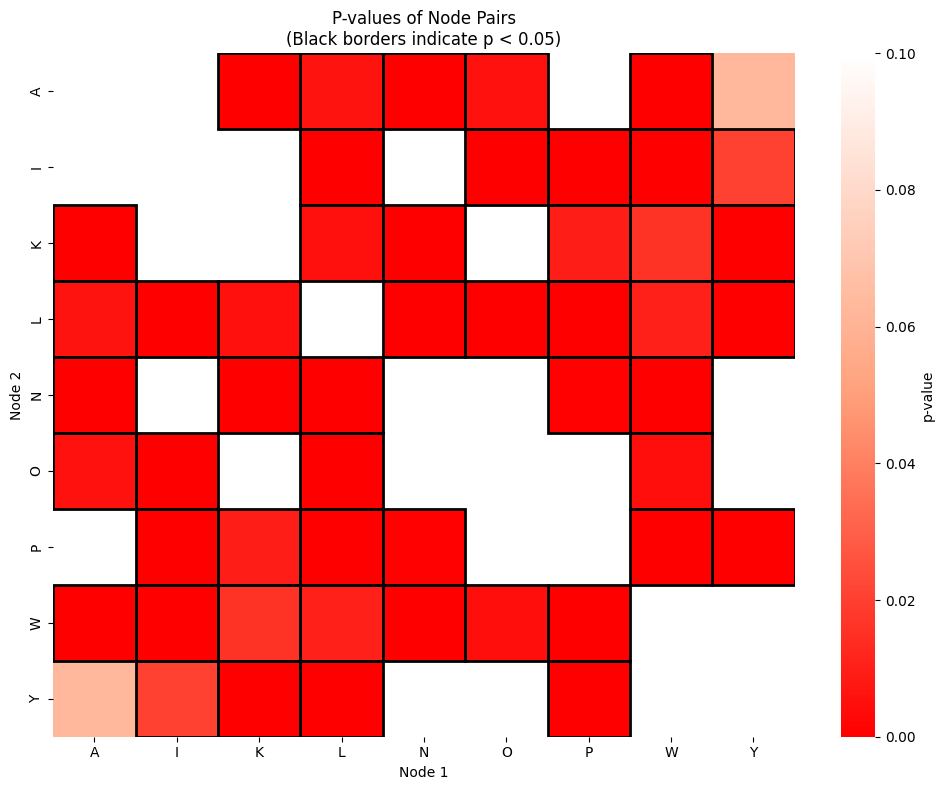

In [ ]:
# Get all unique nodes that appear in either start or end positions
all_nodes = sorted(list(set([n for pair in pairs_with_diff + pairs_no_diff for n in pair])))

# Create matrices to store the significance values and mask
sig_matrix = np.zeros((len(all_nodes), len(all_nodes)))
mask = np.ones((len(all_nodes), len(all_nodes)))

# Fill the matrices
for start, end in pairs_with_diff + pairs_no_diff:
    start_idx = all_nodes.index(start)
    end_idx = all_nodes.index(end)
    sig_matrix[end_idx, start_idx] = pvalues[(start, end)]
    sig_matrix[start_idx, end_idx] = pvalues[(start, end)]
    mask[end_idx, start_idx] = 0
    mask[start_idx, end_idx] = 0

# Set diagonal to light grey by removing mask
for i in range(len(all_nodes)):
    mask[i,i] = 0
    sig_matrix[i,i] = np.nan  # Use NaN to exclude from colormap

# Create custom colormap with dark red for high p-values (less significant)
colors = ['#FF0000', '#FFA07A', '#FFFFFF']  # Red to light salmon to white
n_bins = 100
cmap = sns.blend_palette(colors, n_bins, as_cmap=True)

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(sig_matrix,
            xticklabels=all_nodes,
            yticklabels=all_nodes,
            cmap=cmap,
            mask=mask,
            vmin=0,
            vmax=0.1,  # Adjust this to control color intensity
            cbar_kws={'label': 'p-value'})

# Add black borders to significant squares (p < 0.05)
for i in range(len(all_nodes)):
    for j in range(len(all_nodes)):
        if not mask[i,j] and sig_matrix[i,j] < 0.05 and i != j:  # Skip diagonal
            plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=2))

plt.xlabel('Node 1')
plt.ylabel('Node 2')
plt.title('P-values of Node Pairs\n(Black borders indicate p < 0.05)')
plt.tight_layout()
plt.show()

#### Are women different from men?

In [ ]:
# QUARTILES DIFFERENT
men_flow_trees = []
women_flow_trees = []

min = 99

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    group = group[group["accuracy"]]
    
    men_df = group[group["is_man"]]
    women_df = group[~group["is_man"]]

    min_num_trajs = np.min([women_df.shape[0], men_df.shape[0]])
    if min_num_trajs < 10: continue

    for i in range(5):
        sample_df1 = men_df.sample(n=10, random_state=i) 
        sample_df2 = women_df.sample(n=10, random_state=i) 

        trajs1 = np.array(sample_df1["trajs"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE=node2)
        new_G1 = nx.relabel.convert_node_labels_to_integers(G1, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero


        trajs2 = np.array(sample_df2["trajs"])
        G2 = generate_flow_tree_from_trajs(trajs2, END_NODE=node1)
        new_G2 = nx.relabel.convert_node_labels_to_integers(G2, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero


        men_flow_trees.append(new_G1)
        women_flow_trees.append(new_G2)

print("Do Flow Trees from men and women have different diameters?")
men_diams = np.array([nx.diameter(FT) for FT in men_flow_trees])
women_diams = np.array([nx.diameter(FT) for FT in women_flow_trees])

run_ttest(men_diams, women_diams)
print()
run_permutation_test(men_diams, women_diams)
print()
run_homemade_permutation_test(men_diams, women_diams)


Do Flow Trees from men and women have different diameters?
Group 1 mean: 2.65 (var=1.08; n=200)
Group 2 mean: 3.37 (var=1.50; n=200)
T-statistic: -6.2803, P-value: 0.0000

Permutation test result: -0.715 (p=0.0002)
Mean within group 1 dist: 1.1 (var=0.85)
Mean within group 2 dist: 1.4 (var=1.2)
Mean between all group dist: 1.3 (var=1.1)
Within group 1 dist vs among all: -0.1797 (p=0.0001)
	T-statistic: -22.2399, P-value: 0.0000
Within group 2 dist vs among all: 0.04013 (p=1.0)
	T-statistic: 4.8279, P-value: 0.0000
Within group 1 dist vs within group 2: -0.2198 (p=0.0001)
	T-statistic: -21.8775, P-value: 0.0000

Permutation test: 0.7150 (p=0.0020)


(0.7150000000000003, 0.002)

In [ ]:
print("Do Flow Trees from correct men and women have different embeddings?")
test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
test_flow_tree_embedder.fit(men_flow_trees + women_flow_trees)

men_embeddings = test_flow_tree_embedder.infer(men_flow_trees)
women_embeddings = test_flow_tree_embedder.infer(women_flow_trees)

men_embedding_means = np.array([100*np.mean(x) for x in men_embeddings])
women_embedding_means = np.array([100*np.mean(x) for x in women_embeddings])

run_ttest(men_embedding_means, women_embedding_means)
print()
run_permutation_test(men_embedding_means, women_embedding_means)
print()
run_homemade_permutation_test(men_embeddings, women_embeddings)


Do Flow Trees from correct men and women have different embeddings?
Group 1 mean: 0.00 (var=0.00; n=200)
Group 2 mean: 0.00 (var=0.00; n=200)
T-statistic: -0.0988, P-value: 0.9214

Permutation test result: -0.0003959 (p=0.929)
Mean within group 1 dist: 0.036 (var=0.0017)
Mean within group 2 dist: 0.043 (var=0.0016)
Mean between all group dist: 0.04 (var=0.0016)
Within group 1 dist vs among all: -0.00369 (p=0.0001)
	T-statistic: -11.5497, P-value: 0.0000
Within group 2 dist vs among all: 0.003512 (p=1.0)
	T-statistic: 11.0304, P-value: 0.0000
Within group 1 dist vs within group 2: -0.007203 (p=0.0001)
	T-statistic: -17.8379, P-value: 0.0000

Permutation test: 0.0075 (p=0.0020)


(0.0074568028, 0.002)

#### R/L/F dominant

In [ ]:
overall_RL_labels = {('A', 'I'): 'F', ('A', 'K'): 'F', ('A', 'L'): 'F', ('A', 'N'): 'F', ('A', 'O'): 'R', ('A', 'P'): 'R', ('A', 'W'): 'L', ('A', 'Y'): 'F', ('I', 'A'): 'F', ('I', 'K'): 'R', ('I', 'L'): 'L', ('I', 'N'): 'R', ('I', 'O'): 'R', ('I', 'P'): 'L', ('I', 'W'): 'F', ('I', 'Y'): 'L', ('K', 'A'): 'F', ('K', 'I'): 'L', ('K', 'L'): 'L', ('K', 'N'): 'R', ('K', 'O'): 'R', ('K', 'P'): 'R', ('K', 'W'): 'L', ('K', 'Y'): 'F', ('L', 'A'): 'F', ('L', 'I'): 'R', ('L', 'K'): 'R', ('L', 'N'): 'R', ('L', 'O'): 'R', ('L', 'P'): 'R', ('L', 'W'): 'R', ('L', 'Y'): 'R', ('N', 'A'): 'F', ('N', 'I'): 'L', ('N', 'K'): 'L', ('N', 'L'): 'L', ('N', 'O'): 'L', ('N', 'P'): 'L', ('N', 'W'): 'L', ('N', 'Y'): 'L', ('O', 'A'): 'F', ('O', 'I'): 'L', ('O', 'K'): 'R', ('O', 'L'): 'L', ('O', 'N'): 'R', ('O', 'P'): 'R', ('O', 'W'): 'F', ('O', 'Y'): 'R', ('P', 'A'): 'L', ('P', 'I'): 'F', ('P', 'K'): 'F', ('P', 'L'): 'L', ('P', 'N'): 'R', ('P', 'O'): 'L', ('P', 'W'): 'F', ('P', 'Y'): 'L', ('W', 'A'): 'R', ('W', 'I'): 'L', ('W', 'K'): 'R', ('W', 'L'): 'L', ('W', 'N'): 'R', ('W', 'O'): 'F', ('W', 'P'): 'F', ('W', 'Y'): 'L', ('Y', 'A'): 'F', ('Y', 'I'): 'L', ('Y', 'K'): 'R', ('Y', 'L'): 'L', ('Y', 'N'): 'R', ('Y', 'O'): 'L', ('Y', 'P'): 'R', ('Y', 'W'): 'R'}

racc = []
rft = []
lacc = []
lft = []
facc = []
fft = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    acc = group["path_mean_acc"].iloc[0]

    winners_only = group[~group["accuracy"]]
    trajs = np.array(winners_only["trajs"])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    
    if overall_RL_labels[(start_node, end_node)] == "R":
        racc.append(acc)
        rft.append(new_G)
    elif overall_RL_labels[(start_node, end_node)] == "L":
        lacc.append(acc)
        lft.append(new_G)
    else:
        facc.append(acc)
        fft.append(new_G)


print("Do righthand and lefthand paths have different accuracies?")
group1 = np.array(racc)
group2 = np.array(lacc)
group3 = np.array(facc)

run_ttest(group1, group2)
print()
run_permutation_test(group1, group2)
print()
run_homemade_permutation_test(group1, group2)
print("Right v even:")
run_ttest(group1, group3)
print("Left v even:")
run_ttest(group2, group3)
print()


print("Do righthand and lefthand Flow Trees have different diameters?")
group1 = np.array([nx.diameter(FT) for FT in rft])
group2 = np.array([nx.diameter(FT) for FT in lft])

run_ttest(group1, group2)
print()
run_permutation_test(group1, group2)
print()
run_homemade_permutation_test(group1, group2)

print()
print("Do righthand and lefthand Flow Trees have different embeddings?")
test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
test_flow_tree_embedder.fit(rft + lft + fft)

r_embeddings = test_flow_tree_embedder.infer(rft)
l_embeddings = test_flow_tree_embedder.infer(lft)

# run_ttest(r_embeddings, l_embeddings)
# print()
# run_permutation_test(r_embeddings, l_embeddings)
# print()
run_homemade_permutation_test(r_embeddings, l_embeddings)

Do righthand and lefthand paths have different accuracies?
Group 1 mean: 0.60 (var=0.01; n=27)
Group 2 mean: 0.55 (var=0.01; n=26)
T-statistic: 1.7783, P-value: 0.0813

Permutation test result: 0.04691 (p=0.0862)
Mean within group 1 dist: 0.13 (var=0.0081)
Mean within group 2 dist: 0.081 (var=0.0042)
Mean between all group dist: 0.11 (var=0.0068)
Within group 1 dist vs among all: 0.02134 (p=1.0)
	T-statistic: 4.2463, P-value: 0.0000
Within group 2 dist vs among all: -0.03004 (p=0.0001)
	T-statistic: -6.1356, P-value: 0.0000
Within group 1 dist vs within group 2: 0.05138 (p=1.0)
	T-statistic: 8.4368, P-value: 0.0000

Permutation test: 0.0469 (p=0.1340)
Right v even:
Group 1 mean: 0.60 (var=0.01; n=27)
Group 2 mean: 0.59 (var=0.01; n=19)
T-statistic: 0.3643, P-value: 0.7174
Left v even:
Group 1 mean: 0.55 (var=0.01; n=26)
Group 2 mean: 0.59 (var=0.01; n=19)
T-statistic: -1.4878, P-value: 0.1441

Do righthand and lefthand Flow Trees have different diameters?
Group 1 mean: 10.15 (var=1.83;

(0.014276003, 0.286)

#### Look at start-node Flow Trees

In [ ]:
K_FOLD = 20

start_tree_dict = {}
for start_node, group in test_df[test_df["accuracy"]].groupby(["StartAt"]):
    trees = []
    mean_acc = np.mean(group["path_mean_acc"])
    
    # Generate K_FOLD bootstrapped trees
    for _ in range(K_FOLD):
        # Sample 70% of trajectories
        sampled_group = group.sample(frac=0.7)
        trajs = generate_trajs_from_df(sampled_group)
        G = generate_flow_tree_from_trajs(trajs, END_NODE="1")
        
        # Convert node labels to integers
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
        trees.append(new_G)
        
    start_tree_dict[start_node] = [trees, mean_acc]


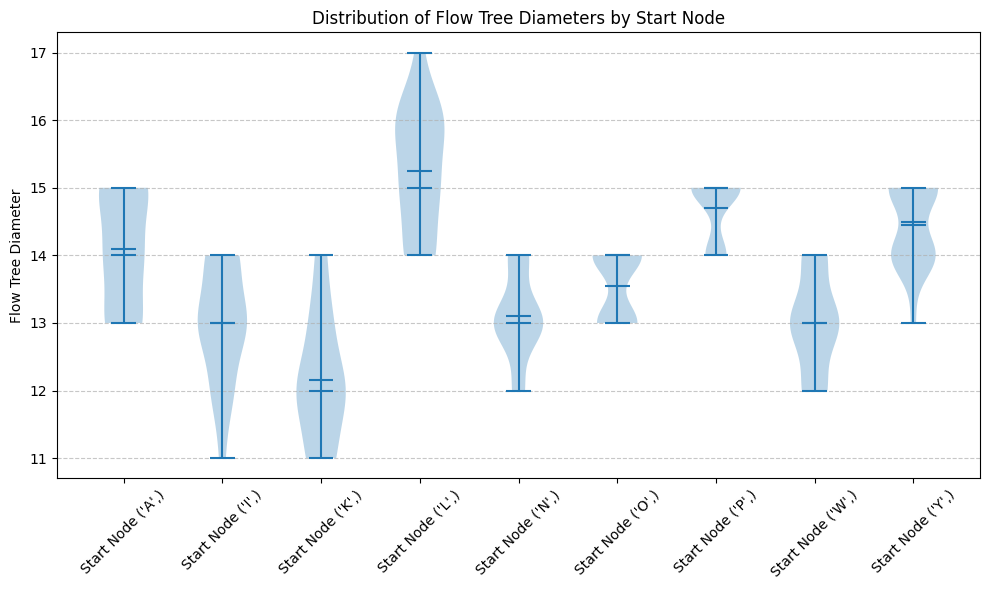

In [ ]:
# Plot distributions of Flow Tree diameters for each start node
plt.figure(figsize=(10, 6))

diameters = []
labels = []
for start_node, (trees, _) in start_tree_dict.items():
    # Calculate diameters for all trees from this start node
    node_diameters = [nx.diameter(tree) for tree in trees]
    diameters.append(node_diameters)
    labels.append(f"Start Node {start_node}")

# Create violin plot
plt.violinplot(diameters, showmeans=True, showmedians=True)
plt.xticks(range(1, len(labels) + 1), labels, rotation=45)
plt.ylabel("Flow Tree Diameter")
plt.title("Distribution of Flow Tree Diameters by Start Node")

# Add grid for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Do Flow Trees from different starting nodes have different diameters?

Summary of Flow Tree Diameter Comparisons (Bonferroni corrected):
------------------------------------------
('A',) vs ('I',): different (p=0.000, corrected threshold=0.001)
('A',) vs ('K',): different (p=0.000, corrected threshold=0.001)
('A',) vs ('L',): different (p=0.000, corrected threshold=0.001)
('A',) vs ('N',): different (p=0.000, corrected threshold=0.001)
('A',) vs ('O',): the same (p=0.018, corrected threshold=0.001)
('A',) vs ('P',): the same (p=0.009, corrected threshold=0.001)
('A',) vs ('W',): different (p=0.000, corrected threshold=0.001)
('A',) vs ('Y',): the same (p=0.142, corrected threshold=0.001)
('I',) vs ('K',): the same (p=0.005, corrected threshold=0.001)
('I',) vs ('L',): different (p=0.000, corrected threshold=0.001)
('I',) vs ('N',): the same (p=0.679, corrected threshold=0.001)
('I',) vs ('O',): the same (p=0.018, corrected threshold=0.001)
('I',) vs ('P',): different (p=0.000, correcte

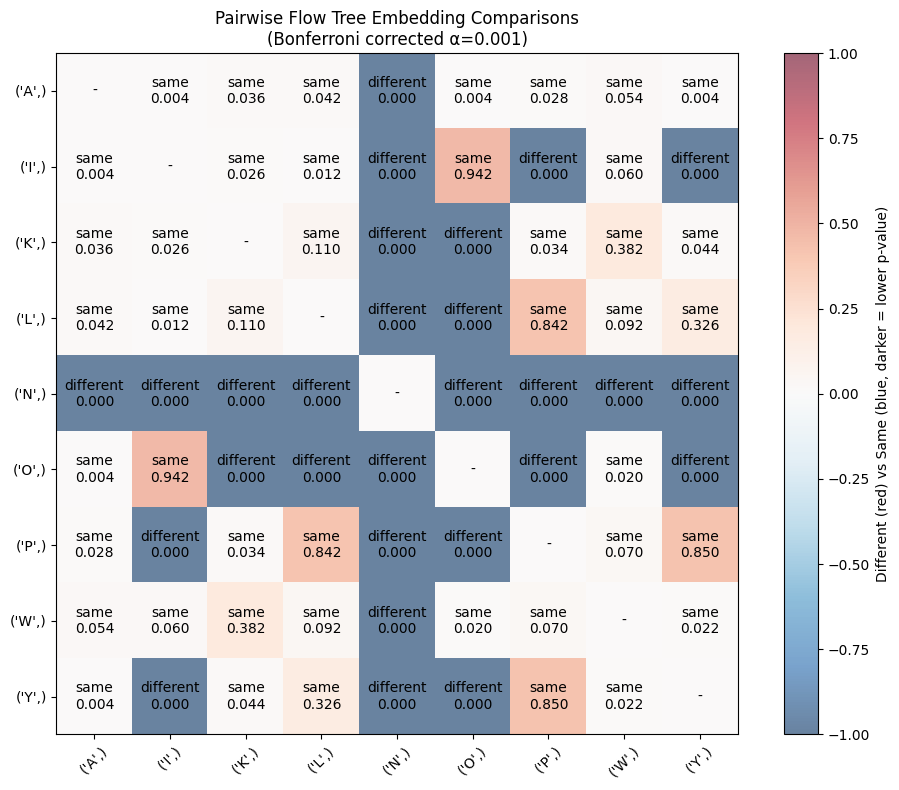

In [ ]:
print("Do Flow Trees from different starting nodes have different diameters?")

# Get all unique start nodes
start_nodes = list(start_tree_dict.keys())

test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)

# Combine all trees for fitting
all_trees = []
for trees, _ in start_tree_dict.values():
    all_trees.extend(trees)
test_flow_tree_embedder.fit(all_trees)

print("\nSummary of Flow Tree Diameter Comparisons (Bonferroni corrected):")
print("------------------------------------------")
n_comparisons = (len(start_nodes) * (len(start_nodes) - 1)) // 2  # Number of pairwise comparisons
alpha = 0.05 / n_comparisons  # Bonferroni correction

for i in range(len(start_nodes)):
    for j in range(i+1, len(start_nodes)):
        node1 = start_nodes[i] 
        node2 = start_nodes[j]
        
        group1 = np.array([nx.diameter(FT) for FT in start_tree_dict[node1][0]])
        group2 = np.array([nx.diameter(FT) for FT in start_tree_dict[node2][0]])
        
        # Run t-test
        t_stat, p_val = stats.ttest_ind(group1, group2)
        
        result = "different" if p_val < alpha else "the same"
        print(f"{node1} vs {node2}: {result} (p={p_val:.3f}, corrected threshold={alpha:.3f})")

print("\nSummary of Flow Tree Embedding Comparisons (Bonferroni corrected):") 
print("-------------------------------------------")
for i in range(len(start_nodes)):
    for j in range(i+1, len(start_nodes)):
        node1 = start_nodes[i]
        node2 = start_nodes[j]
        
        embeddings1 = test_flow_tree_embedder.infer(start_tree_dict[node1][0])
        embeddings2 = test_flow_tree_embedder.infer(start_tree_dict[node2][0])
        
        # Calculate distances within and between groups
        dist1 = pdist(embeddings1)
        dist2 = pdist(embeddings2)
        dist_between = pdist(np.vstack([embeddings1, embeddings2]))
        
        # Calculate test statistic and p-value
        observed = np.mean(dist_between) - (np.mean(dist1) + np.mean(dist2))/2
        
        # Get p-value from previous test
        n_perms = 500
        count = 0
        for _ in range(n_perms):
            combined = np.vstack([embeddings1, embeddings2])
            np.random.shuffle(combined)
            perm1 = combined[:len(embeddings1)]
            perm2 = combined[len(embeddings1):]
            
            dist1_perm = pdist(perm1)
            dist2_perm = pdist(perm2)
            dist_between_perm = pdist(combined)
            
            perm_stat = np.mean(dist_between_perm) - (np.mean(dist1_perm) + np.mean(dist2_perm))/2
            if abs(perm_stat) >= abs(observed):
                count += 1
                
        p_val = count/n_perms
        
        result = "different" if p_val < alpha else "the same"
        print(f"{node1} vs {node2}: {result} (p={p_val:.3f}, corrected threshold={alpha:.3f})")

# Create a matrix to store p-values
n_nodes = len(start_nodes)
p_value_matrix = np.zeros((n_nodes, n_nodes))
significance_matrix = np.zeros((n_nodes, n_nodes))

# Fill matrices
for i in range(len(start_nodes)):
    for j in range(len(start_nodes)):
        if i < j:
            node1 = start_nodes[i]
            node2 = start_nodes[j]
            
            embeddings1 = test_flow_tree_embedder.infer(start_tree_dict[node1][0]) # 0 index is trees, 1 is acc
            embeddings2 = test_flow_tree_embedder.infer(start_tree_dict[node2][0])
            
            # Calculate distances within and between groups
            dist1 = pdist(embeddings1)
            dist2 = pdist(embeddings2)
            dist_between = pdist(np.vstack([embeddings1, embeddings2]))
            
            # Calculate test statistic
            observed = np.mean(dist_between) - (np.mean(dist1) + np.mean(dist2))/2
            
            # Get p-value from permutation test
            n_perms = 500
            count = 0
            for _ in range(n_perms):
                combined = np.vstack([embeddings1, embeddings2])
                np.random.shuffle(combined)
                perm1 = combined[:len(embeddings1)]
                perm2 = combined[len(embeddings1):]
                
                dist1_perm = pdist(perm1)
                dist2_perm = pdist(perm2)
                dist_between_perm = pdist(combined)
                
                perm_stat = np.mean(dist_between_perm) - (np.mean(dist1_perm) + np.mean(dist2_perm))/2
                if abs(perm_stat) >= abs(observed):
                    count += 1
            
            p_val = count/n_perms
            p_value_matrix[i,j] = p_val
            p_value_matrix[j,i] = p_val
            significance_matrix[i,j] = p_val < alpha  # Using Bonferroni corrected threshold
            significance_matrix[j,i] = p_val < alpha
# Plot heatmap
plt.figure(figsize=(10,8))

# Create custom color matrix based on p-values and significance
color_matrix = np.zeros_like(significance_matrix, dtype=float)
for i in range(n_nodes):
    for j in range(n_nodes):
        if significance_matrix[i,j]:  # Different - use blue
            color_matrix[i,j] = -1
        else:  # Same - use red with gradient based on p-value
            color_matrix[i,j] = p_value_matrix[i,j] * 0.5  # Scale down red intensity

plt.imshow(color_matrix, cmap='RdBu_r', vmin=-1, vmax=1, alpha=0.6)  # Add transparency
plt.colorbar(label='Different (red) vs Same (blue, darker = lower p-value)')

# Add text annotations
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            text = 'different' if significance_matrix[i,j] else 'same'
            plt.text(j, i, f'{text}\n{p_value_matrix[i,j]:.3f}', 
                    ha='center', va='center')
        else:
            plt.text(j, i, '-', ha='center', va='center')

plt.xticks(range(n_nodes), start_nodes, rotation=45)
plt.yticks(range(n_nodes), start_nodes)
plt.title('Pairwise Flow Tree Embedding Comparisons\n(Bonferroni corrected α={:.3f})'.format(alpha))
plt.tight_layout()
plt.show()

# what if you only have relative information but no absolute direct access
# use movement t/ group dynamics to identify geometry of the space


(9, 20, 64)


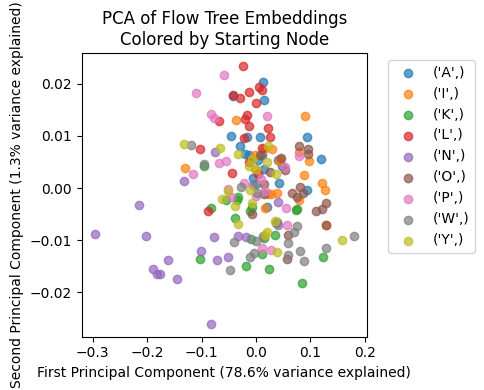

In [ ]:
# Perform PCA on all embeddings
from sklearn.decomposition import PCA
# First pad all embeddings to same length
padded_embeddings = []
for node in start_nodes:
    node_embeddings = test_flow_tree_embedder.infer(start_tree_dict[node][0])
    # Pad with zeros if needed
    padded_embeddings.append(node_embeddings)

all_embeddings = np.array(padded_embeddings)
print(all_embeddings.shape)
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings.reshape(-1, all_embeddings.shape[-1]))

# Create plot
plt.figure(figsize=(5,4))

# Plot points for each starting node with different colors
start_idx = 0
for i, node in enumerate(start_nodes):
    node_embeddings = start_tree_dict[node][0]
    end_idx = start_idx + len(node_embeddings)
    plt.scatter(embeddings_2d[start_idx:end_idx, 0], 
               embeddings_2d[start_idx:end_idx, 1],
               label=node,
               alpha=0.7)
    start_idx = end_idx
# Get explained variance ratios
explained_var = pca.explained_variance_ratio_ * 100

plt.xlabel(f'First Principal Component ({explained_var[0]:.1f}% variance explained)')
plt.ylabel(f'Second Principal Component ({explained_var[1]:.1f}% variance explained)')
plt.title('PCA of Flow Tree Embeddings\nColored by Starting Node')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Think of more gender questions:
- Is there difference in predictive power in women or men?


- Early v late in the test phase

Path questions:
- Can you tell from the flow tree if the path has a foil?


Hypothesis test -- permute trajectories of people doing flow tree vs doing it over just flow trees!

What is the range of path lengths people have when they get it wrong?

Are foils related to start or related to intended target?


right paths v left-leaning paths -- categoriacal variable and also continuous (proportion of rights and lefts among winners)

## THIS